# Visualization Notebook

This notebook generates all primary figures for the manuscript on global urban road network
flood resilience.

Documentation Note: Portions of this documentation were drafted with the assistance of Claude (Anthropic) and subsequently reviewed, edited, and verified for technical accuracy by the authors.

---

# Import Libraries

In [1]:
# ── Standard library ────────────────────────────────────────────────────────────
import os
import math
from itertools import pairwise
import ast
import re
import pickle

# ── Data wrangling ──────────────────────────────────────────────────────────────
import pandas as pd
import geopandas as gpd
import numpy as np
from tqdm import tqdm

# ── Geometry ────────────────────────────────────────────────────────────────────
from shapely.geometry import Point, Polygon, box, LineString

# ── Visualisation ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LogNorm
from matplotlib import rcParams
import seaborn as sns

# ── Scientific computing ────────────────────────────────────────────────────────
import scipy.optimize
from scipy.stats import gaussian_kde
from scipy.interpolate import make_interp_spline
from scipy.interpolate import interp1d
from scipy.interpolate import Rbf, InterpolatedUnivariateSpline
from scipy.interpolate import make_interp_spline, BSpline
from scipy.interpolate import BSpline

In [2]:
# Set home directory
home_dir = '/Users/yiyi/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Research/Global road network resilience/01_data' # CURA
home_dir = '/Users/yiyi/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology(2)/Research/Global road network resilience/01_data' # SCARP
# home_dir = '/Users/yiyi/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Research/Global road network resilience/01_data' # Home

---
## Figure 1e — Direct Flood Exposure

**Objective:** Quantify what share of each urban road network is directly inundated at ten flood return periods (RP 5–1000 years) under four depth thresholds (0.15 m, 0.20 m, 0.25 m, 0.30 m).

**Key outputs:**
- `exposure_tot_meters` — inundated road length (m) per network × RP × threshold
- `exposure_tot_percentage` — same normalised by total road length (%)
- `threshold_stack` — long-format table with a `threshold` column, used for grouped box plots

**Figure produced:** Notched box plot — distribution of inundation percentages across
~2,616 networks, faceted by depth threshold (hue) and return period (x-axis).
Threshold sensitivity increases visibly at longer return periods.

In [4]:
home_dir

'/Users/yiyi/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Research/Global road network resilience/01_data'

In [ ]:
# exposure dfs
btw_79_90_exposure_raw = pd.read_csv(home_dir + "/csv/flood_exposure_percent_79_90_flooded_649_records.csv", index_col=0)
grth_90_exposure_raw = pd.read_csv(home_dir + "/csv/flood_exposure_percent_grth_90_flooded_1967_records.csv", index_col=0)
exposure_raw_combined = pd.concat(
    [btw_79_90_exposure_raw, grth_90_exposure_raw],
    axis=0
)

# exposure in total meters
exposure_tot_meters = exposure_raw_combined.reset_index().rename(columns={'index':'id'})
# exposure_tot_meters.to_csv(home_dir + "/csv/exposure_tot_meter_2616_records.csv")

# exposure in percentage
exposure_tot_percentage = exposure_tot_meters[['id', 'total_road_length']].join(exposure_tot_meters.iloc[:,1:-1].div(exposure_tot_meters.total_road_length /100, axis=0))
# exposure_tot_percentage.to_csv(home_dir + "/csv/exposure_tot_percentage_2616_records.csv")

In [ ]:
# Reshape the wide exposure table into long format.
# For each depth threshold in [0.15, 0.20, 0.25, 0.30] m, extract the ten
# RP columns, rename them to a uniform RP_* scheme, and stack vertically.
# The resulting threshold_stack has columns: id, RP_5 … RP_1000, threshold.
# This tidy format is required by seaborn's hue parameter in the box plot below.
exposure_tot_percentage.drop(columns=['total_road_length'])
thresholds = [0.15, 0.2, 0.25, 0.3]

threshold_stack = pd.DataFrame()
for threshold in thresholds:
    threshold_df = exposure_tot_percentage.filter(regex=str(threshold)+'$',axis=1)
    threshold_df.columns = ['RP_5', 'RP_10', 'RP_20', 'RP_50', 'RP_75', 'RP_100',
                            'RP_200', 'RP_250', 'RP_500', 'RP_1000']
    threshold_df = exposure_tot_percentage[['id']].join(threshold_df)
    threshold_df['threshold'] = threshold
    threshold_stack = pd.concat([threshold_stack, threshold_df], ignore_index=True)

# Save the stacked version as new csv file
threshold_stack.to_csv(home_dir + "/csv/exposure_tot_percentage_2616_records_stacked.csv")

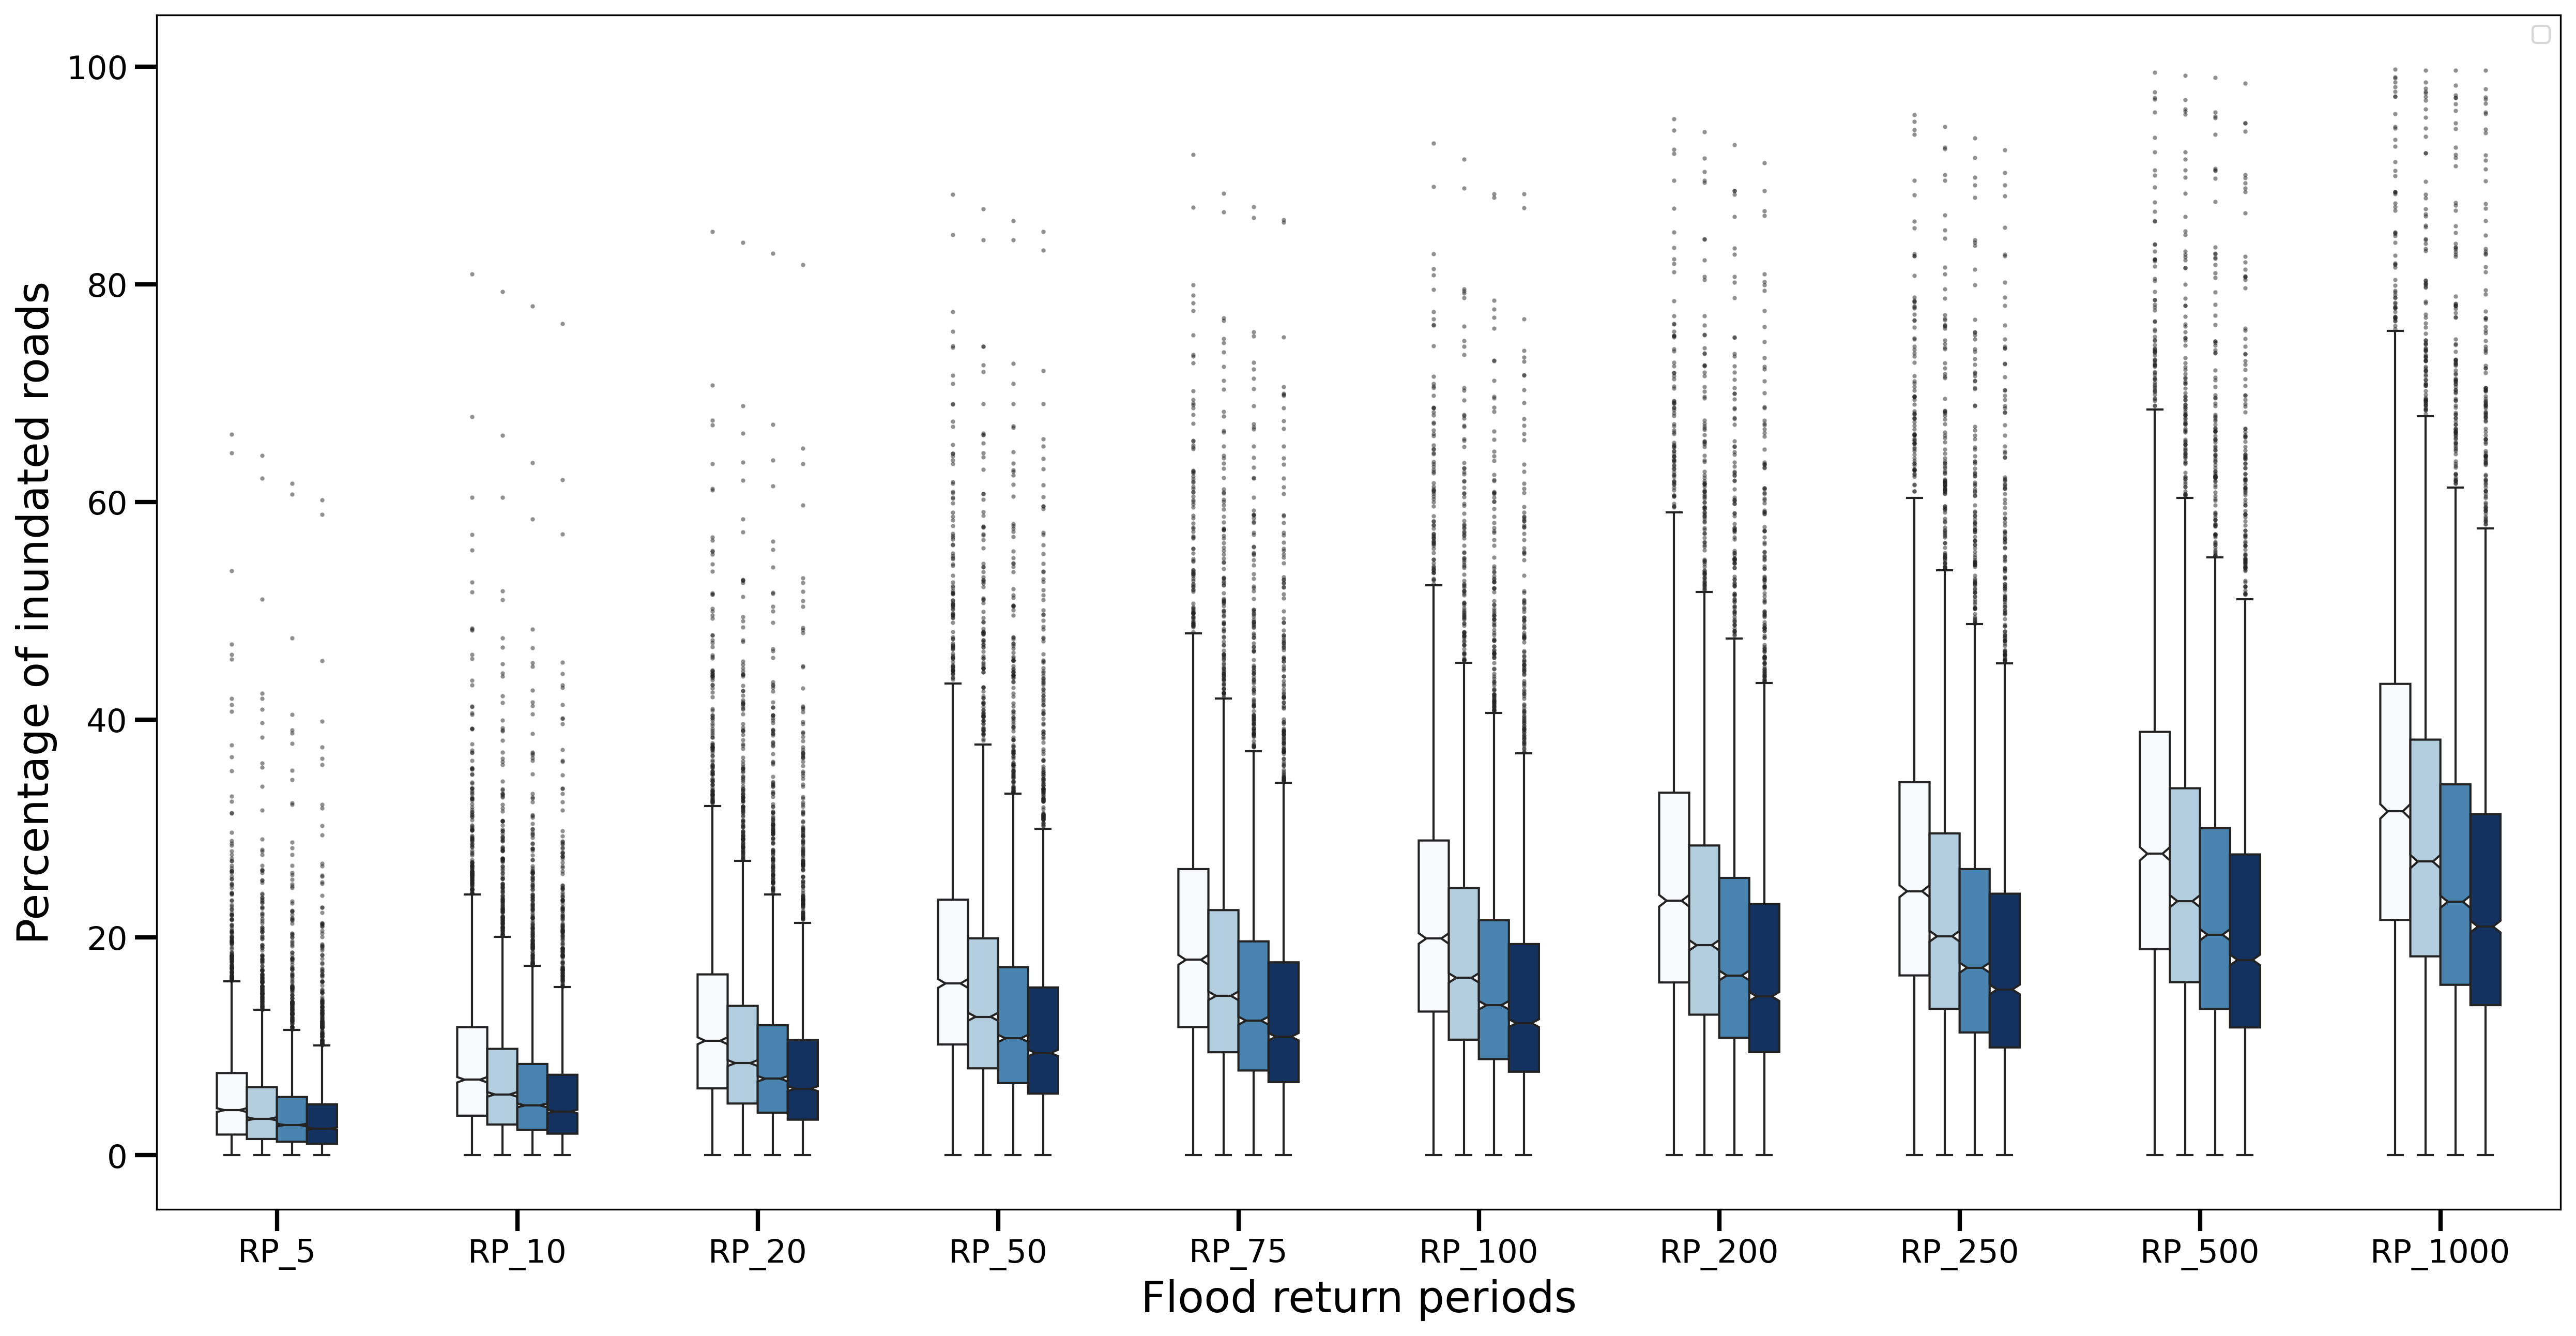

In [15]:
# Figure 1e — Notched box plot of direct flood exposure.
# Melt threshold_stack to long format so each row is one (network, RP, threshold)
# observation. Notches indicate 95 % CI around the median.
# The 'ocean' palette encodes depth threshold; x-axis encodes return period.
# Flier (outlier) markers are reduced in size and alpha to avoid overplotting.
threshold_stack = pd.read_csv(home_dir + "/csv/exposure_tot_percentage_2616_records_stacked.csv", index_col=0)
plt.figure(dpi=300, figsize=(20,10))

df_melt = pd.melt(threshold_stack, id_vars=['id', 'threshold'], 
                  value_vars=['RP_5', 'RP_10', 'RP_20', 'RP_50', 'RP_75',
                              'RP_100', 'RP_200', 'RP_250', 'RP_500', 'RP_1000'])

sns.boxplot(x="variable", y="value", hue="threshold", data=df_melt, palette="Blues", notch=True, width=0.5,
            flierprops = dict(markersize = 1, alpha=0.5))

plt.xticks(fontsize = 15)
plt.xlabel('Flood return periods', fontsize = 20)
plt.yticks(fontsize = 15)
plt.ylabel('Percentage of inundated roads', fontsize = 20)
plt.legend('')
plt.tick_params(length=10, width=2)

---
## Figure 1f — Travel Delay and Distance Increase under Flooding

**Depth thresholds:** 15, 20, 25, and 30 cm (hue in the box plots).
**Return periods:** RP 5–1000 (x-axis).

**Figures produced:**
- Box plot of average travel delay (s), capped at 720 s (12 min) for readability
- Box plot of average detour distance increase (m), capped at 10 km

In [22]:
plt.figure(dpi=300, figsize=(40,25))

rps = [5, 10, 20, 50, 75, 100, 200, 250, 500, 1000]
df_melt = pd.melt(drop_na_concat, id_vars=['net_id', 'threshold'], 
                  value_vars=['FUP' + str(rp) + '_avg_dis_increase' for rp in rps])

sns.boxplot(x="variable", y="value", hue="threshold", data=df_melt, palette="Reds",
            notch=True, width=0.6,
            flierprops = dict(markersize = 1, alpha=0.5))

plt.xticks(fontsize = 15)
plt.xlabel('flood return periods', fontsize = 20)
plt.yticks([1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000], fontsize = 15)
plt.ylabel('travel distance increase meters', fontsize = 20)
plt.legend('')
# plt.yscale('log')
plt.tick_params(length=15, width=4)
sns.despine()
plt.ylim(ymax=10000, ymin=0)
# plt.savefig('/Users/yiyihe/Desktop/WorldBank/City_Resilience/04_maps/travel_delay_dis_increase_dropna/travel_distance_increase_dropna.png')

(0.0, 10000.0)

---
## Figure 2a — Country-Level Scatter Plot (Exposure vs. Routing Failure)

**Settings:** RP = 100, threshold = 30 cm (representative scenario).

**Figure produced:** Bubble scatter plot — x = average exposure %, y = average
routing-failure %, bubble size proportional to number of urban networks in country,
colour encodes World Bank region (Paired palette). Legend placed outside axes.
The 1:1 diagonal separates countries where flooding causes disproportionate
disruption (above) from those with high physical exposure but resilient topology (below).

Text(0, 0.5, 'Percentage failed routes (avg)')

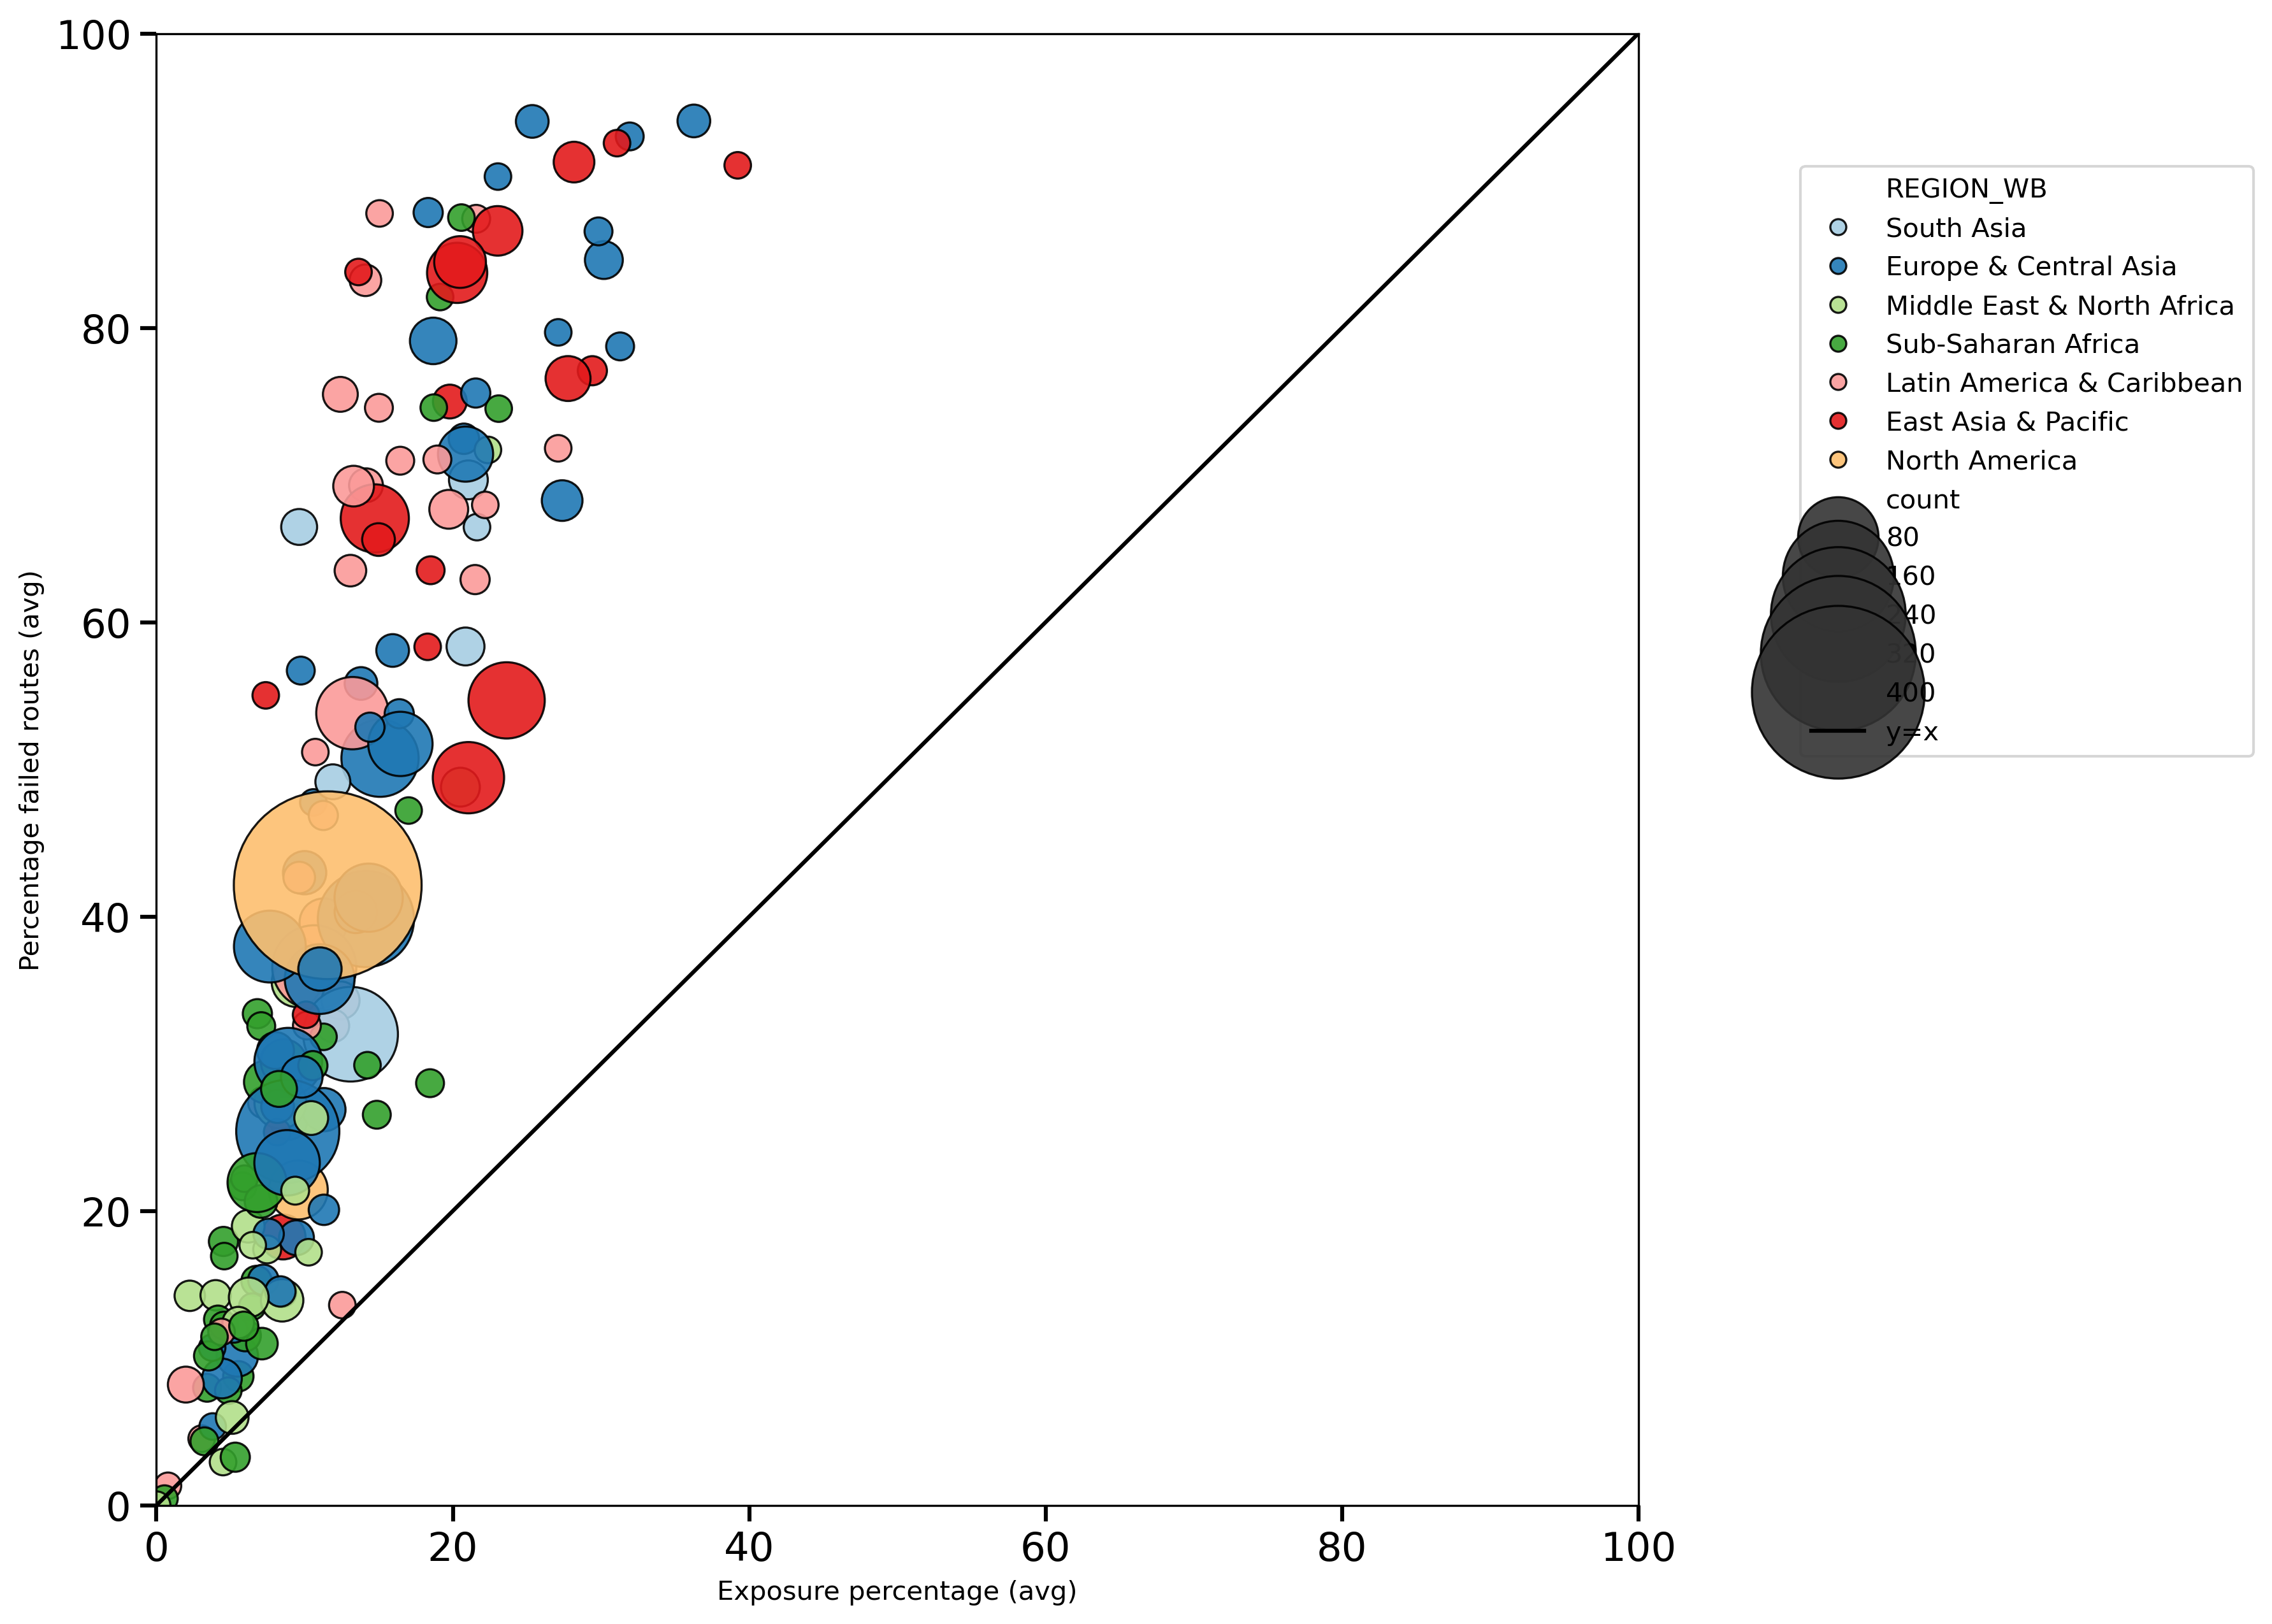

In [ ]:
# Load aggregated country-level file (RP 100, 30 cm threshold).
# Columns: ExpoPerc (avg exposure %), PercFail (avg routing failure %),
# REGION_WB (World Bank region), count (number of networks in country).
# The file path note references the shared OneDrive location for collaborators.
rp = 100
threshold = 30
# Exposure: RP_5_threshold_0.3
# The csv file can be found in the shared OneDrive folder "Perc_fail_exposure_RP100_30cm_by_country.csv"
fail_exposure_by_country_count_attri = pd.read_csv(home_dir + "/csv/Perc_fail_exposure_RP100_30cm_by_country.csv",
                                                   index_col=0)

# Plot
plt.figure(dpi=300, figsize=(10,10))
g = sns.scatterplot(data=fail_exposure_by_country_count_attri,
                x='ExpoPerc',
                y='PercFail',
                hue='REGION_WB', size='count', edgecolor="black", alpha=0.9,
                palette="Paired",
                sizes=(100, 5000), legend=True)

# # y=x line
x = np.linspace(0,100,100)
plt.plot(x, x, '-k', label='y=x')

plt.xlim(xmin=0, xmax=100)
plt.ylim(ymin=0, ymax=100)

plt.xticks(np.arange(0, 101, step=20), fontsize=15)
plt.yticks(np.arange(0, 101, step=20), fontsize=15)
plt.tick_params(length=6, width=1.5)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=5)

plt.xlabel('Exposure percentage (avg)')
plt.ylabel('Percentage failed routes (avg)')

---
## Figure 4b — Ternary Phase Diagram

**Three axes (all converted to percentile ranks 0–1):**
- **Exposure** (`exposure_rk`) — direct flood exposure at RP 100
- **Cosine similarity** (`cosine_rk`) — travel-route vs. flood-direction alignment
  (high cosine = routes run parallel to flood extent → more vulnerable)
- **GCC size** (`gcc_size_rk`) — size of the giant connected component after
  flooding (normalised by node count); measures network fragmentation

**Figures produced:**
- Full global ternary scatter (all 2569 networks), coloured by WB region
- Ternary plot filtered to US Northeast high-cosine outlier networks
- Empty ternary reference frame for annotation in figure editing software

In [ ]:
# Full ternary phase diagram for all networks.
# Three feature columns are rank-transformed (pct=True → 0–1 percentile) so
# the ternary axes are directly comparable regardless of original units.
# Plotly's scatter_ternary is used because it natively supports the simplex
# coordinate system. Region colours follow the WB standard scheme.
import plotly.express as px
import plotly.io as pio
import kaleido

pio.templates.default = "none"

parameters_df_concat = pd.read_csv(home_dir + '/csv/3_ft_parameters_df.csv', index_col=0)

# Add country information
network_country_attri_df = pd.read_csv(home_dir +'/csv/net_4190_join_country_attri_raw.csv',
                                       index_col=0)
parameters_country_merge = pd.merge(parameters_df_concat,
                                    network_country_attri_df[['net_id', 'REGION_WB']],
                                    left_on='net_id',
                                    right_on='net_id')

# Convert parameter columns to percentile ranks
parameters_country_merge['exposure_rk'] = parameters_country_merge.exposure_rp100.rank(pct = True)
parameters_country_merge['cosine_rk'] = parameters_country_merge.cosine_depth30cm_freq90th_RP100.rank(pct = True)
parameters_country_merge['gcc_size_rk'] = parameters_country_merge.gcc_num_nodes_node_norm.rank(pct = True)

fig = px.scatter_ternary(parameters_country_merge,
                         a="exposure_rk",
                         b="cosine_rk",
                         c="gcc_size_rk",
                         color  = 'REGION_WB',
                         color_discrete_map = {"Europe & Central Asia": "rgb(59, 119, 175)",
                                               "North America": "rgb(244, 193, 123)",
                                               "East Asia & Pacific": "rgb(209, 53, 43)",
                                               "Middle East & North Africa": "rgb(187, 221, 147)",
                                               "South Asia": "rgb(174, 205, 226)",
                                               "Latin America & Caribbean": "rgb(238, 159, 156)",
                                               "Sub-Saharan Africa": "rgb(84, 157, 62)"},
                        width=1000, height=1000)
fig.show()
# fig.write_image('/Users/yiyi/Desktop/newplot.png',
#                 scale=10)

---
## Figure SI-1a — Direct Exposure by Inundation Depth (0–5 m Sensitivity)

**Method:** B-spline interpolation (k = 9) smooths the raw aggregated curve
to highlight the non-linear relationship between depth threshold and exposure.

**Figure produced:** Multi-line plot — one curve per return period, coloured
by the RdYlBu diverging palette (blue = short RP, red = long RP).
Curves converge at high depth thresholds because even rare events do not
universally exceed 5 m inundation.

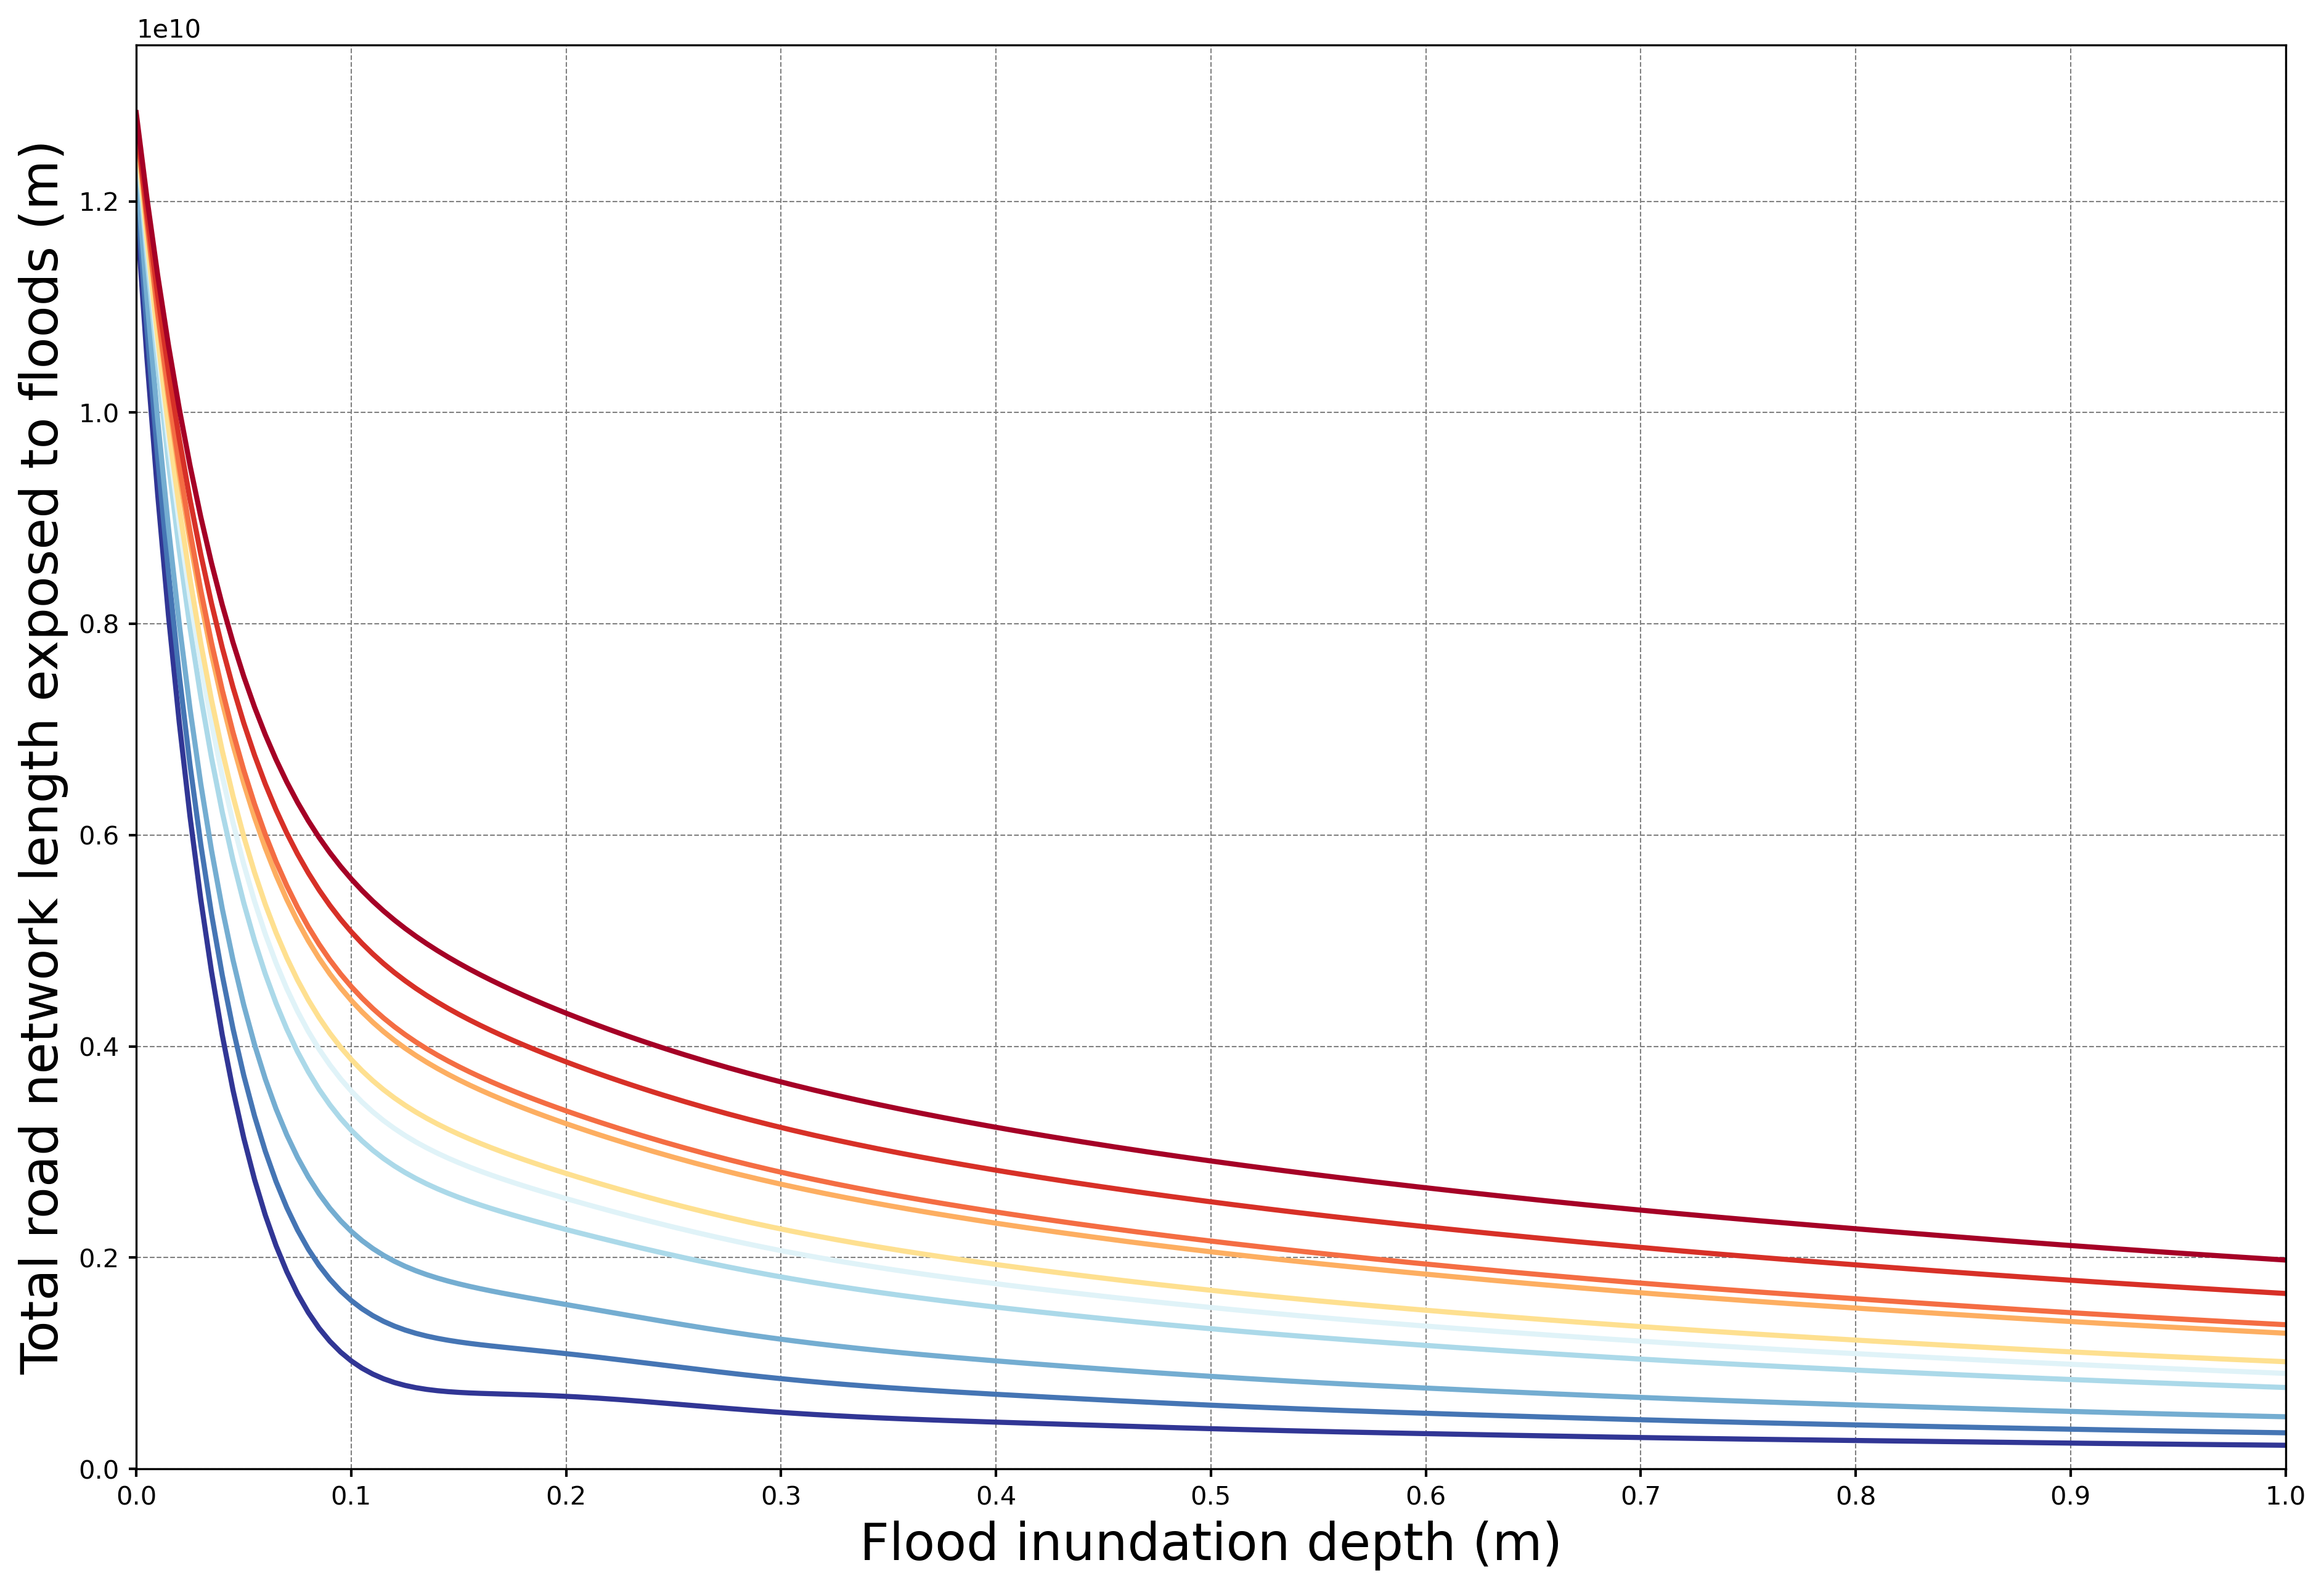

In [18]:
# Aggregate exposure sensitivity data by return period.
# exposure_sensitivity_raw contains one row per (network, depth_threshold, RP).
# Grouping by RP and summing gives total global road length exposed at each
# depth–RP combination. The result is pivoted so columns are RPs and rows are
# depth thresholds (0–5 m in increments from the raw data).
#
# B-spline smoothing (scipy make_interp_spline, k=9) is applied per RP
# to produce publication-quality smooth curves. Higher-order splines (k=9)
# are appropriate here because the underlying function is expected to be smooth.
exposure_sensitivity_raw = pd.read_csv(home_dir + '/csv/exposure_sensitivity_raw_summary.csv',
                                      index_col=0)
exposure_by_rp = exposure_sensitivity_raw.groupby(['RP']).sum()

flood_10_rps = [5, 10, 20, 50, 75, 100, 200, 250, 500, 1000]
colors = ['#313695', '#4575b4', '#74add1', '#abd9e9', '#e0f3f8',
          '#fee090', '#fdae61', '#f46d43', '#d73027', '#a50026']

df = exposure_by_rp.loc[:, exposure_by_rp.columns.drop('net_id')].T

def model_func(t, A, K, C):
    return A * np.exp(K * t) + C
def fit_exp_nonlinear(t, y):
    opt_parms, parm_cov = scipy.optimize.curve_fit(model_func, t, y, maxfev=100000)
    A, K, C = opt_parms
    return A, K, C

plt.figure(dpi=300, figsize=(15,10))
for i, rp  in enumerate(flood_10_rps):
    x = np.array([float(i) for i in df.index])
    y = df[rp].values
    
    X_Y_Spline = make_interp_spline(x, y)
    cubic_interploation_model = interp1d(x, y, kind = "quadratic")
    ius = InterpolatedUnivariateSpline(x, y)
    rbf = Rbf(x, y)
    
#     A, K, C = fit_exp_nonlinear(x, y)
#     fit_y = model_func(x, A, K, C)
    
    X_ = np.linspace(x.min(), x.max(), 1000)
#     Y_ = cubic_interploation_model(X_)
    

    spl = make_interp_spline(x, y, k=9)  # type: BSpline
    Y_ = spl(X_)
    
    plt.plot(X_, Y_, color=colors[i], linewidth=2)
#     plt.plot(x, fit_y, color=colors[i])
#     plt.plot(x, y, color=colors[i], label=rp)

plt.xlim(xmin=0, xmax=1)
plt.ylim(ymin=0)
plt.xticks(x[:11])
plt.xlabel('Flood inundation depth (m)', fontsize = 20)
plt.ylabel('Total road network length exposed to floods (m)', fontsize = 20)
plt.tick_params(length=3, width=1)
plt.grid(True, color='grey', linestyle='--', linewidth=0.5, zorder=0)
# plt.legend()
# plt.yscale('log')
# plt.xscale('symlog')
# plt.yscale('log')
# plt.savefig(f'/Users/yiyihe/Desktop/direct_exposure_by_inundation.png')

---
## Figure SI-1b — Percent Failed Routings vs. Percent Exposure

**Key variables:**
- `FUP_<RP>` — fraction of failed O-D routings at a given return period
- `RP_<RP>` — direct exposure percentage at the same RP

**Figure produced:** Scatter plot with all 10 RPs overlaid; the 1:1 reference line
highlights networks where indirect impact exceeds (above line) or falls short of
(below line) what direct exposure alone would predict.
A systematic offset above the diagonal indicates that network topology amplifies
physical exposure into disproportionate routing failures.

In [ ]:
# Merge failed-routing and exposure tables for a selected depth threshold.
# Iterates over ten return periods, left-joining on net_id each time,
# to produce a single wide DataFrame with paired fail_perc_* / expose_perc_* columns.
# threshold_value = 25 cm depth cutoff (road edge flagged as flooded if
# inundation depth ≥ 25 cm).
# Read percent failed routings dataframe
failed_routings_df = pd.read_csv(home_dir + '/csv/percent_failed_routes/percent_failed_routings_df.csv', index_col=0)
# Read percent exposure dataframe
exposure_tot_percentage_stacked_df = pd.read_csv(home_dir + '/csv/flood_exposure/exposure_tot_percentage_2616_records_stacked.csv', index_col=0)

threshold_value = 25
# Set flood return period
# List of flood return periods
flood_10_rps = [5, 10, 20, 50, 75, 100, 200, 250, 500, 1000]
fail_exposure_percentage_join_10_rps = failed_routings_df[failed_routings_df['threshold'] == 15][['net_id']]

for RP_value in flood_10_rps:
    
    failed_routings_df_select = failed_routings_df[['net_id']].join(\
        failed_routings_df[failed_routings_df['threshold']==threshold_value].filter(\
        regex='P_'+str(RP_value)+'$',axis=1)).dropna()
    exposure_tot_percentage_select = exposure_tot_percentage_stacked_df[['id']].join(\
        exposure_tot_percentage_stacked_df[exposure_tot_percentage_stacked_df['threshold']==(threshold_value/100)].filter(\
        regex='P_'+str(RP_value)+'$',axis=1)).dropna()

    fail_exposure_percentage_join = pd.merge(failed_routings_df_select, exposure_tot_percentage_select,
                                            left_on='net_id', right_on='id', how='left').\
                                    rename(columns={'FUP_'+str(RP_value): 'fail_perc_'+str(RP_value),
                                                  'RP_'+str(RP_value): 'expose_perc_'+str(RP_value)}).\
                                    drop(columns='id')
    
    fail_exposure_percentage_join_10_rps = pd.merge(fail_exposure_percentage_join_10_rps,
                                                    fail_exposure_percentage_join,
                                                    left_on='net_id',
                                                    right_on='net_id')
fail_exposure_percentage_join_10_rps['threshold'] = threshold_value
fail_exposure_percentage_join_10_rps.to_csv(home_dir + '/csv/fail_exposure_percentage_join_10_rps_'\
                                            + str(threshold_value)\
                                            + 'cm.csv')

(0.0, 100.0)

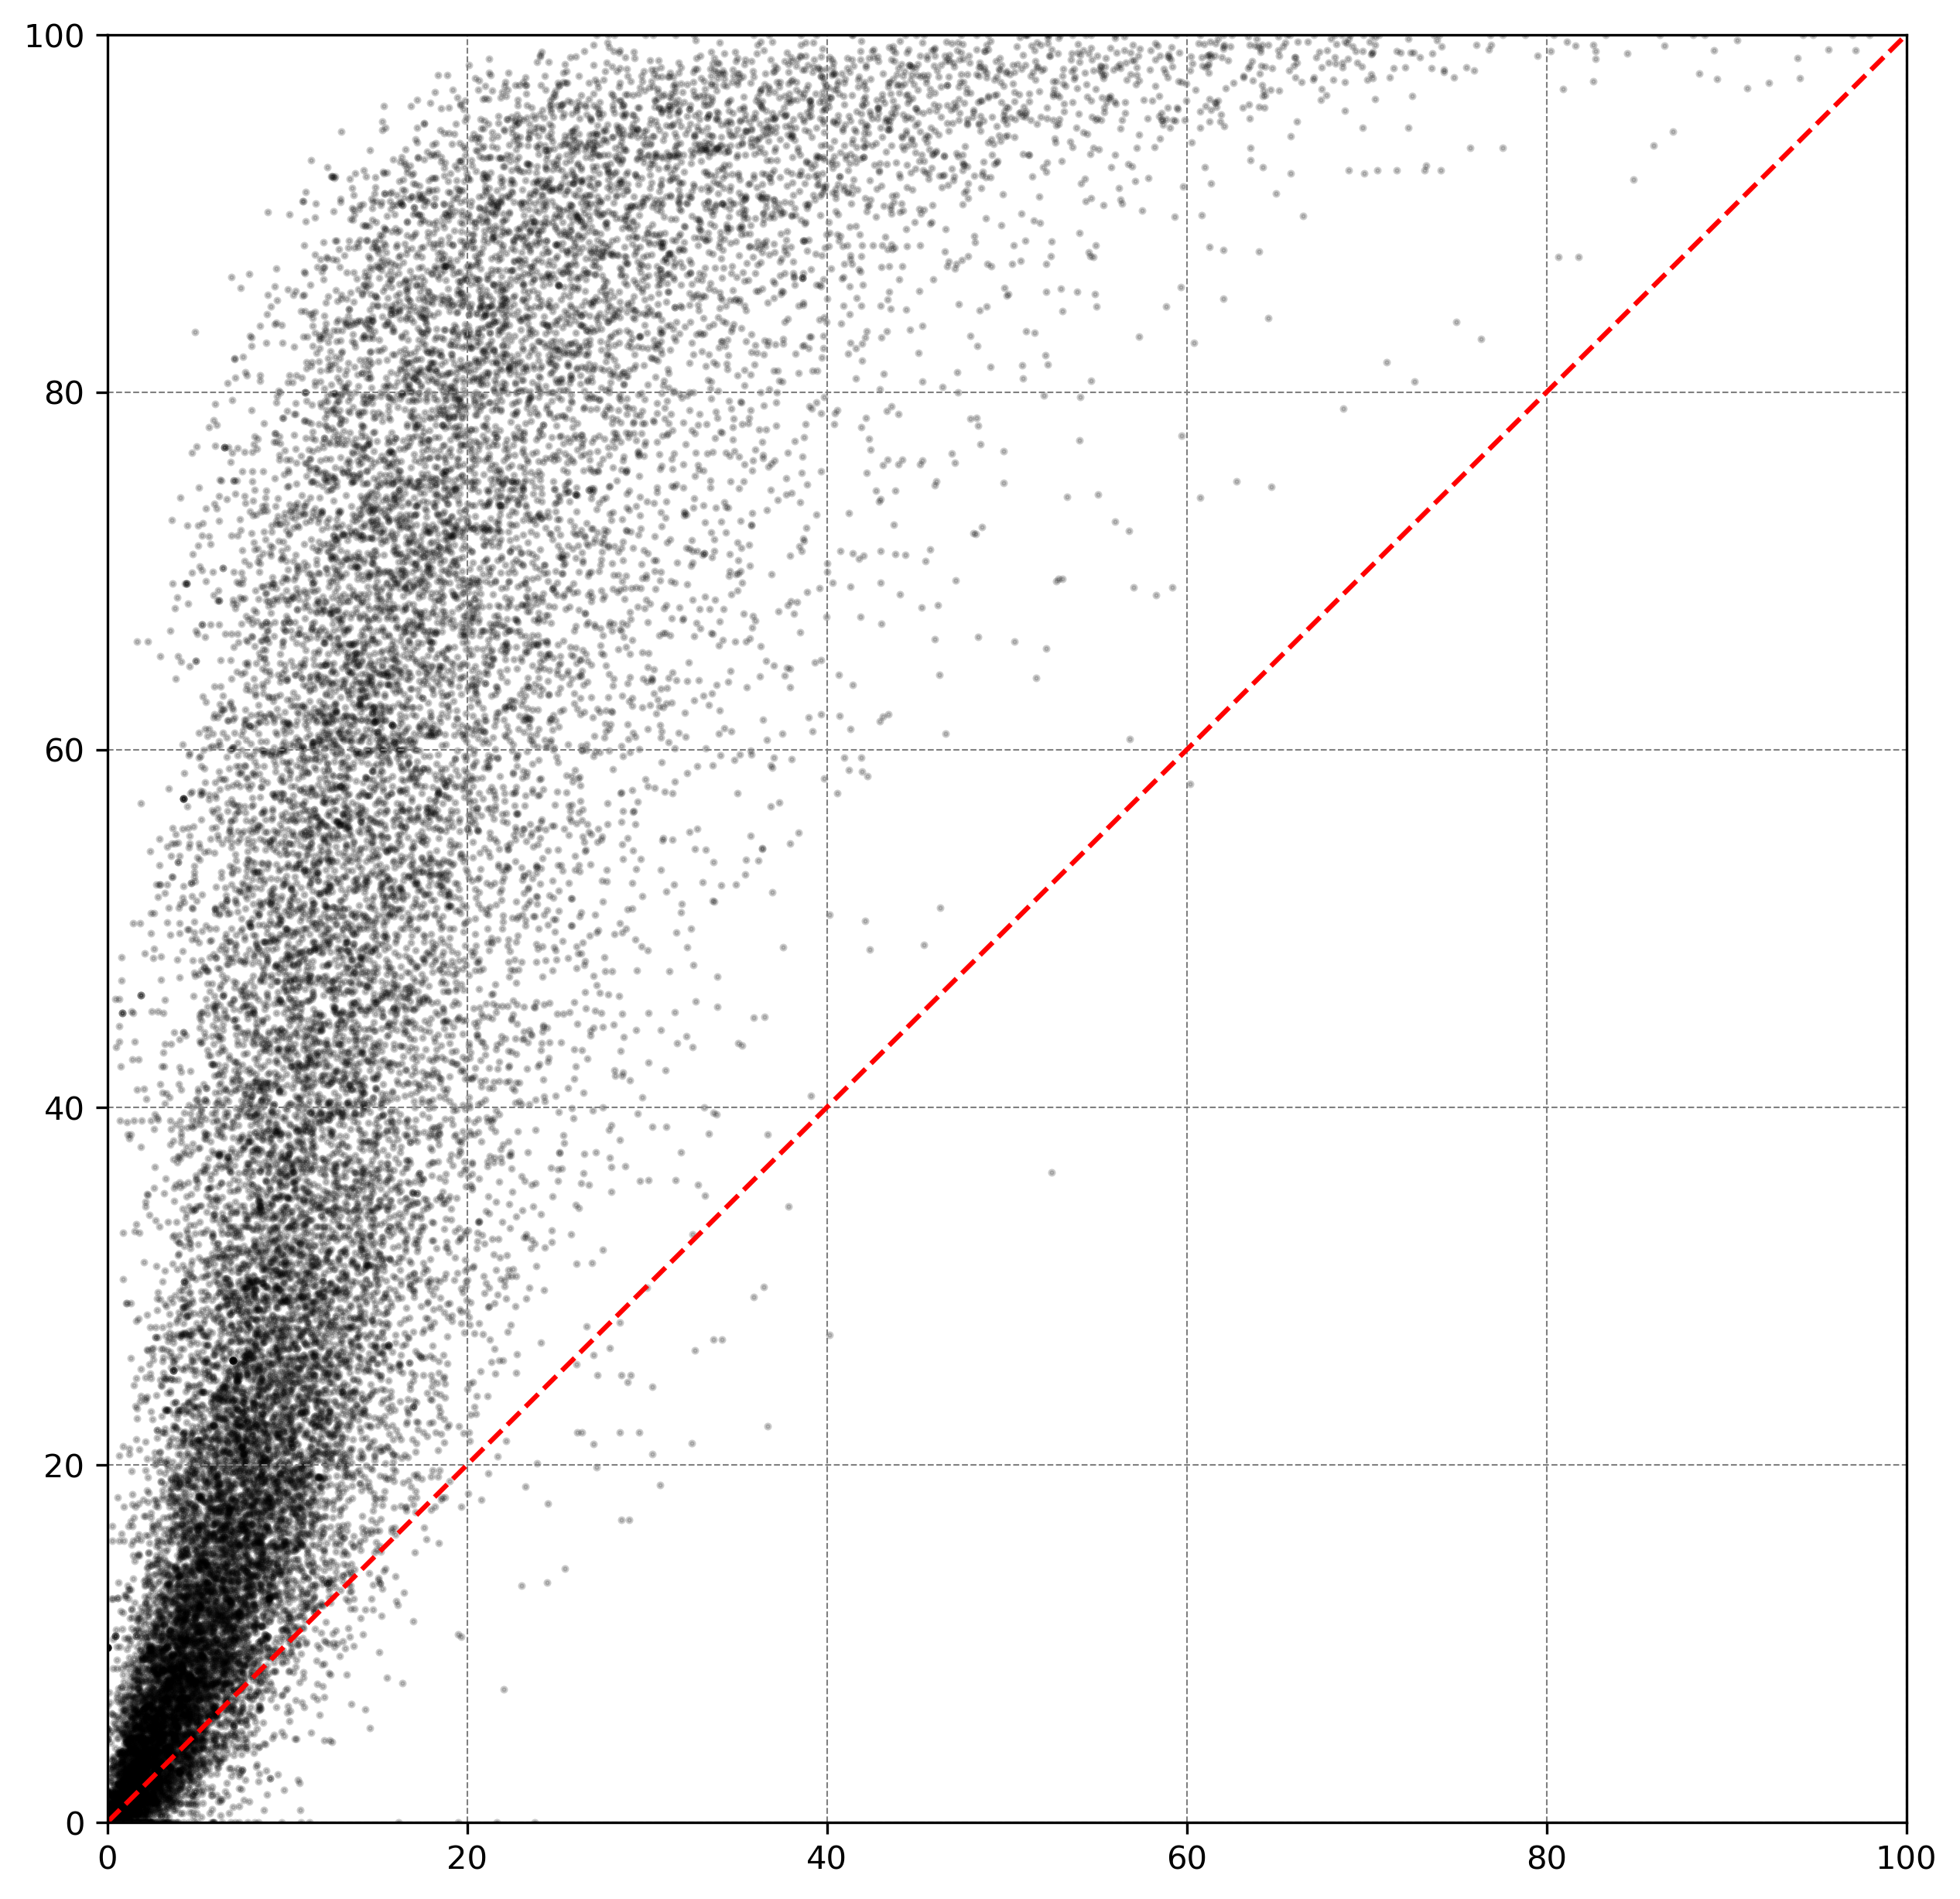

In [16]:
# Scatter plot
flood_10_rps = [5, 10, 20, 50, 75, 100, 200, 250, 500, 1000]
colors = ['#313695', '#4575b4', '#74add1', '#abd9e9', '#e0f3f8',
          '#fee090', '#fdae61', '#f46d43', '#d73027', '#a50026']
# https://colorbrewer2.org/#type=diverging&scheme=RdYlBu&n=10
# Read dataframe
fail_exposure_percentage_join_10_rps = pd.read_csv(home_dir + '/csv/fail_exposure_percentage_join_10_rps_30cm.csv',
                                                  index_col=0)

plt.figure(dpi=300, figsize=(10,10))
for i, rp in enumerate(flood_10_rps):
    plt.scatter(fail_exposure_percentage_join_10_rps[f'expose_perc_{rp}'].values,
                fail_exposure_percentage_join_10_rps[f'fail_perc_{rp}'].values, c='k',
               alpha=0.2, s=8, marker='.')

plt.plot([0, 100], [0, 100], c='r', linestyle='--')
plt.grid(True, color='grey', linestyle='--', linewidth=0.5, zorder=0)
plt.xlim(xmin=0, xmax=100)
plt.ylim(ymin=0, ymax=100)
# plt.savefig(f'/Users/yiyihe/Desktop/percent_expo_percent_failed_scatter.png')

---
## Figure SI-7 — Direct and indirect storm surge impacts on coastal road networks across hurricane intensity levels

**Data:** `graph_exposure_percent_failed_routes_merged.csv` — one row per network,
columns `CAT*_expo_perc` and `OD_perc_fail_CAT*` for each hurricane category.

Load in the exposure and percentage of failed routes dataframe consisting of records for 55 networks along the US coast.

In [32]:
exposure_failed_merged = pd.read_csv(home_dir + '/Coastal_flooding/graph_exposure_percent_failed_routes_merged.csv', index_col=0)

In [33]:
exposure_failed_merged.head(3)

,net_id,total_length,CAT1_expo,CAT2_expo,CAT3_expo,CAT4_expo,CAT5_expo,CAT1_expo_perc,CAT2_expo_perc,CAT3_expo_perc,CAT4_expo_perc,CAT5_expo_perc,network_id,OD_perc_fail_CAT1,OD_perc_fail_CAT2,OD_perc_fail_CAT3,OD_perc_fail_CAT4,OD_perc_fail_CAT5
0,2085,1348523.855,19999.088,79803.592,184285.671,413596.909,569879.608,1.483036,5.917848,13.665733,30.670344,42.259513,2085,11.347518,19.148936,60.992908,79.432624,85.815603
1,1971,425753.174,0.000,0.000,0.000,13451.927,43072.903,0.000000,0.000000,0.000000,3.159560,10.116872,1971,0.000000,0.000000,0.000000,1.438849,4.316547
2,1732,1422628.727,16024.839,48288.704,116226.498,259921.775,436510.502,1.126425,3.394329,8.169841,18.270528,30.683375,1732,6.040268,6.040268,13.422819,40.268456,85.234899


/var/folders/cy/f8598vm53cggn74m01d5s0rc0000gr/T/ipykernel_70696/1516554355.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Blues")   # alternatives: "magma", "plasma", "cividis", "BrBG"
/var/folders/cy/f8598vm53cggn74m01d5s0rc0000gr/T/ipykernel_70696/1516554355.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


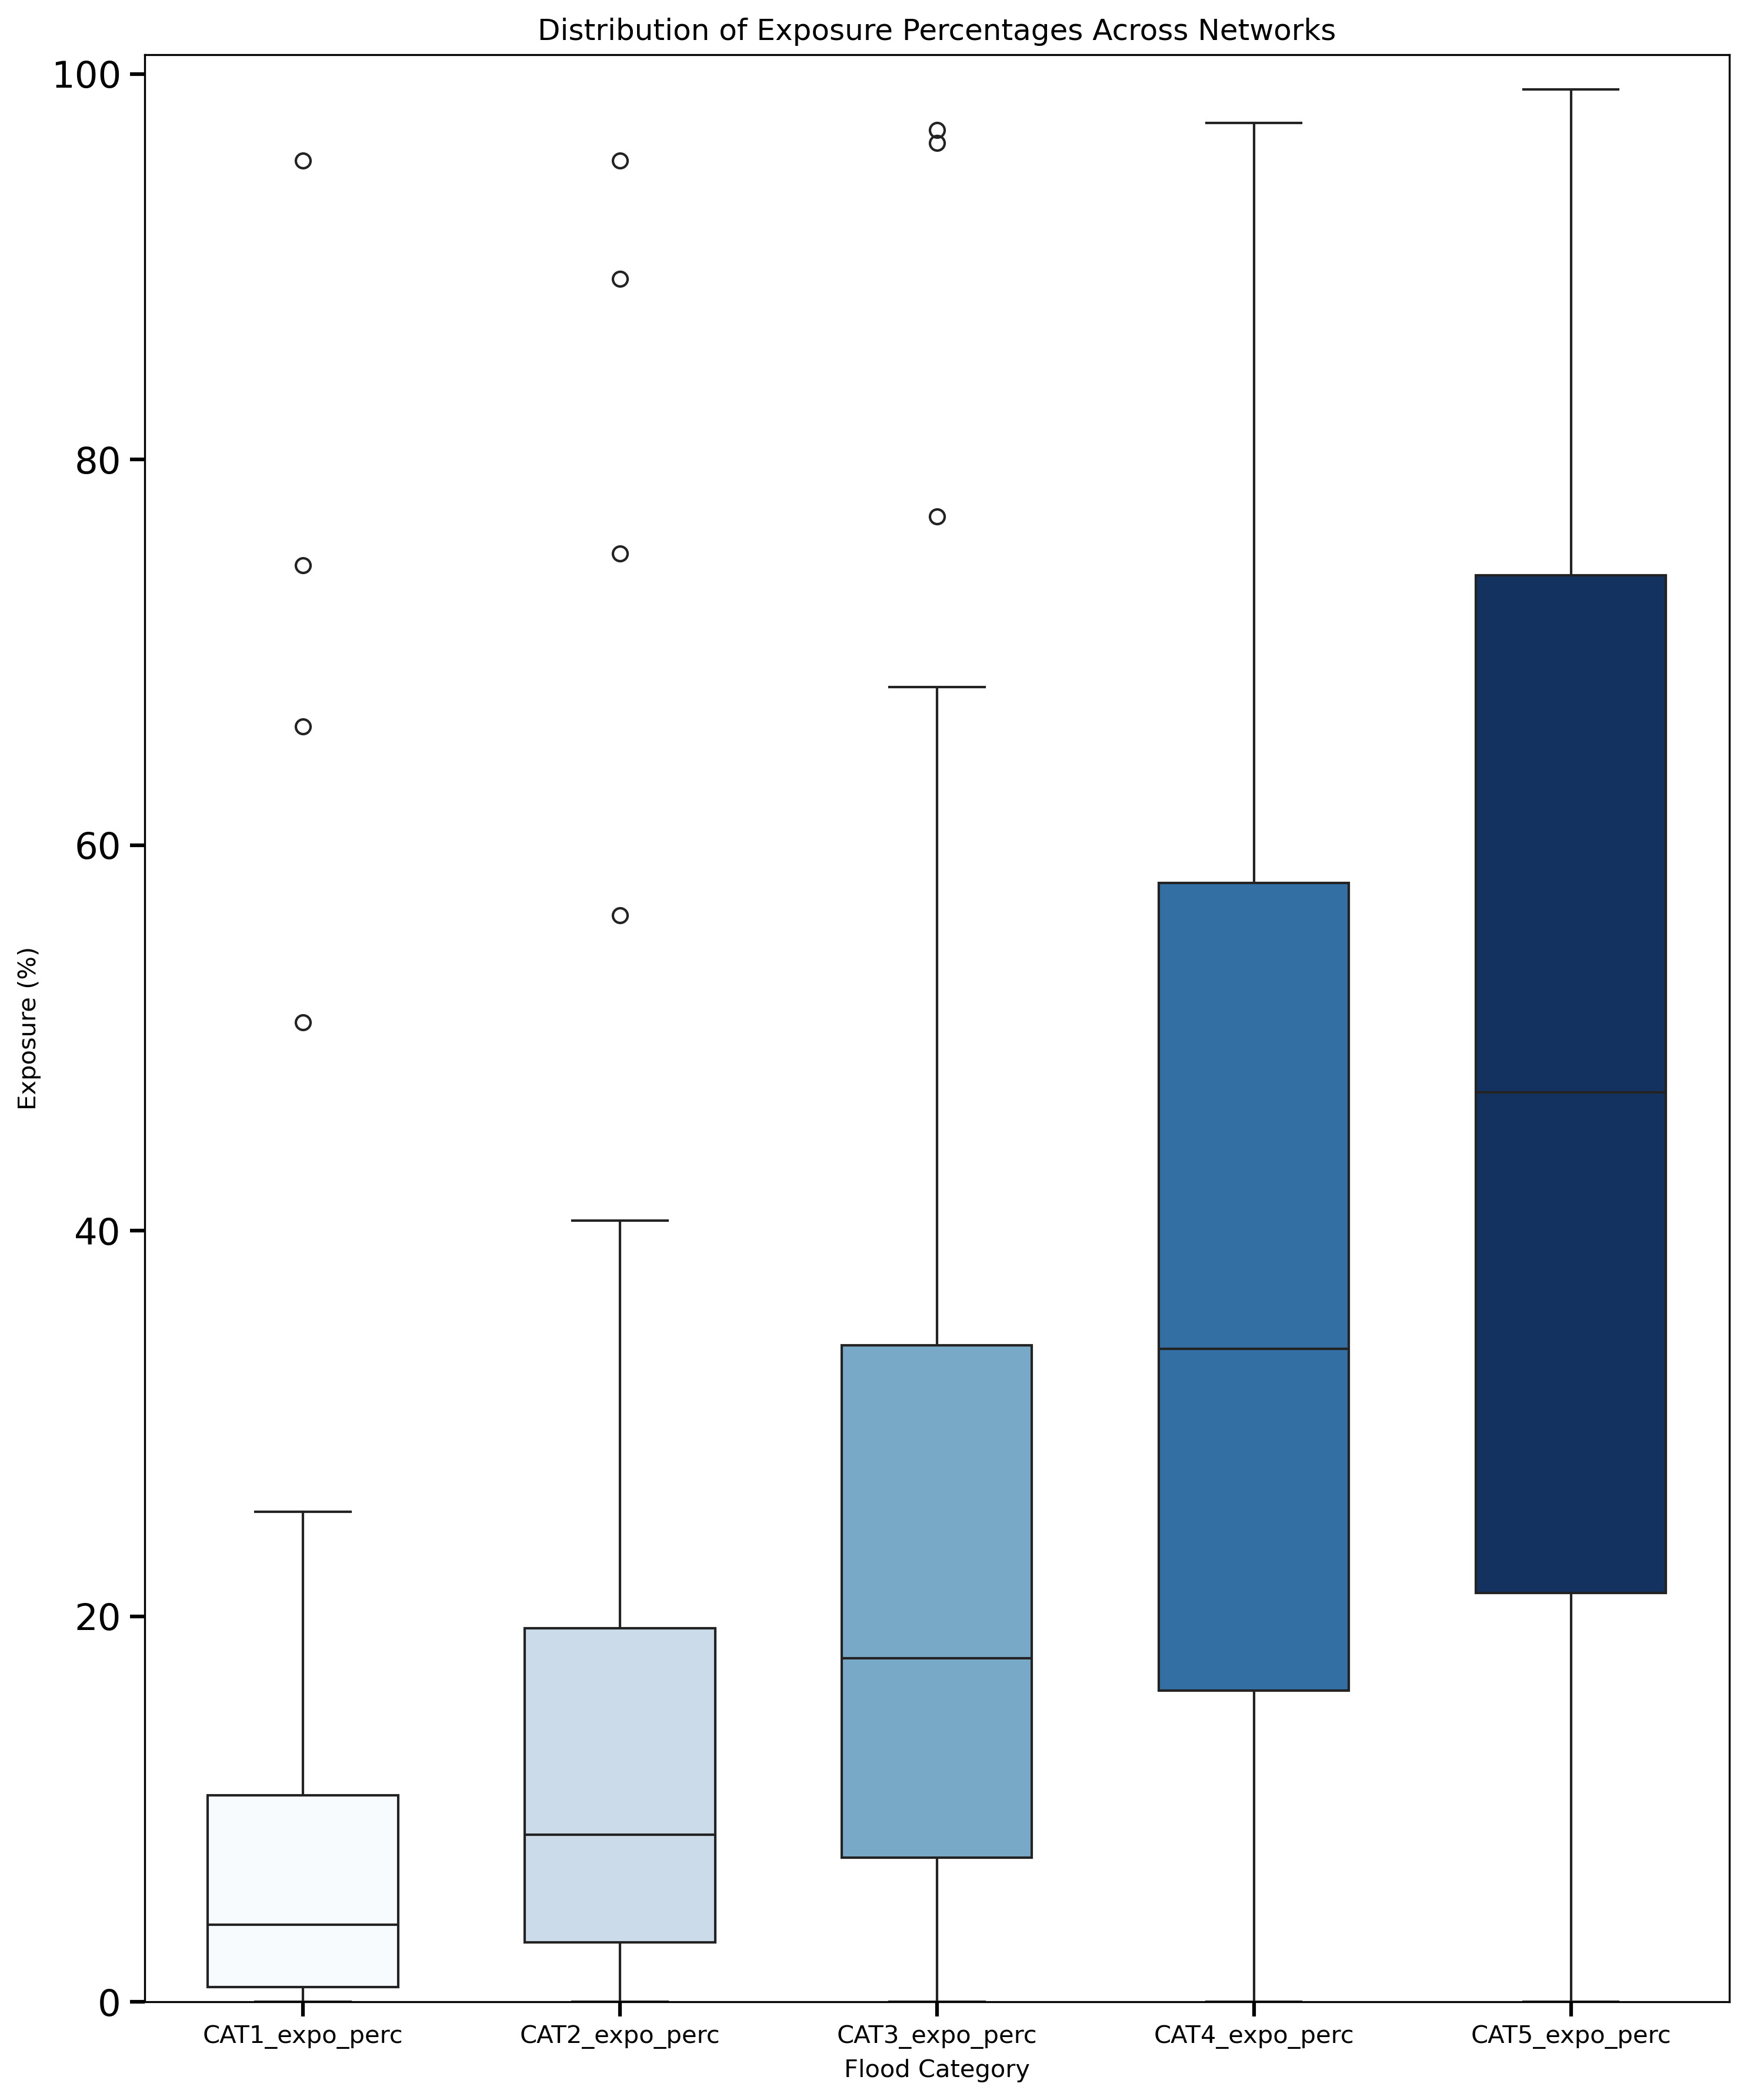

In [ ]:
# Blues sequential palette: lighter blue = lower category (less intense).
# Y-axis runs 0–100 % to show the full plausible range. Outliers shown.
pct_cols = ["CAT1_expo_perc", "CAT2_expo_perc", "CAT3_expo_perc", "CAT4_expo_perc", "CAT5_expo_perc"]

df_long = exposure_failed_merged.melt(
    value_vars=pct_cols,
    var_name="Category",
    value_name="Exposure (%)"
)

cmap = cm.get_cmap("Blues")   # alternatives: "magma", "plasma", "cividis", "BrBG"
palette = [cmap(i) for i in np.linspace(0, 1, len(pct_cols))]

plt.figure(dpi=300, figsize=(10,12))
sns.boxplot(
    data=df_long,
    x="Category",
    y="Exposure (%)",
    palette=palette,
    showfliers=True,
    width=0.6
)
plt.ylim(ymin=0, ymax=101)

plt.yticks(np.arange(0, 101, step=20), fontsize=15)
plt.tick_params(length=6, width=1.5)

plt.xlabel("Flood Category")
plt.ylabel("Exposure (%)")
plt.title("Distribution of Exposure Percentages Across Networks")
plt.tight_layout()
plt.show()

/var/folders/cy/f8598vm53cggn74m01d5s0rc0000gr/T/ipykernel_34025/1218861828.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Reds")   # alternatives: "magma", "plasma", "cividis", "BrBG"
/var/folders/cy/f8598vm53cggn74m01d5s0rc0000gr/T/ipykernel_34025/1218861828.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


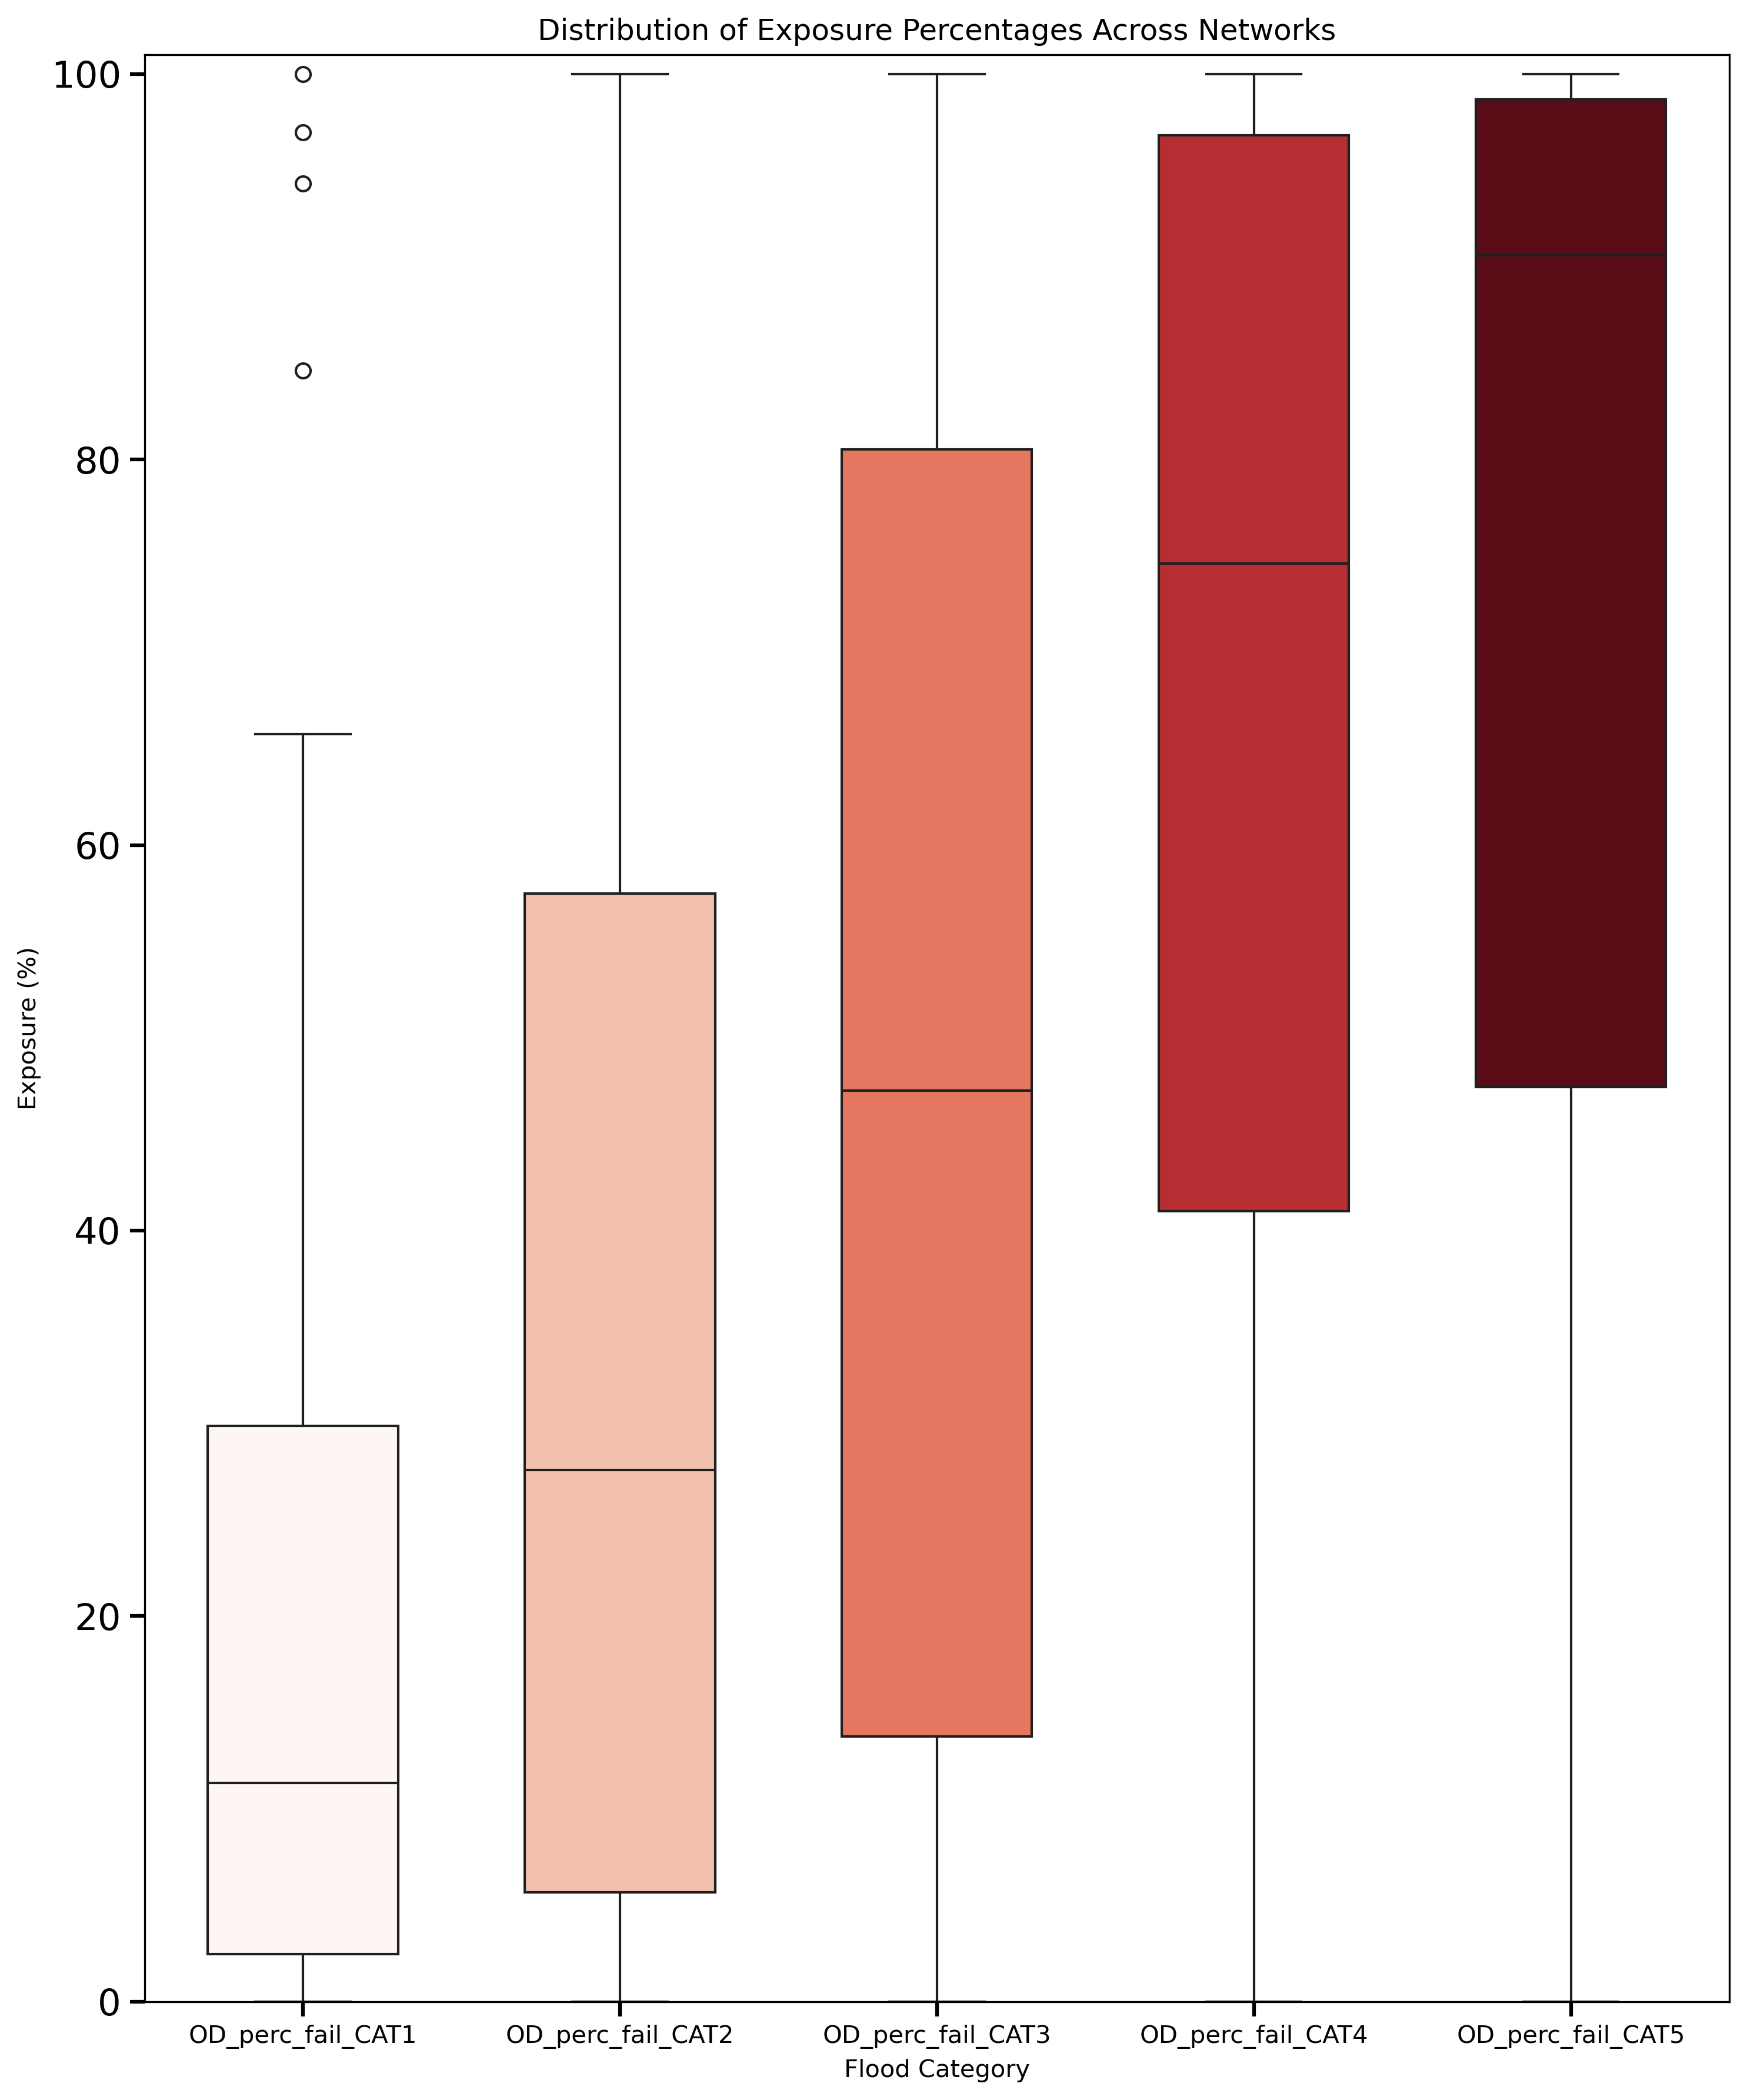

In [ ]:
# Reds palette mirrors the exposure plot for visual consistency.
# Same axis limits (0–101 %) enable direct comparison
pct_cols = ["OD_perc_fail_CAT1", "OD_perc_fail_CAT2", "OD_perc_fail_CAT3", "OD_perc_fail_CAT4", "OD_perc_fail_CAT5"]

df_long = exposure_failed_merged.melt(
    value_vars=pct_cols,
    var_name="Category",
    value_name="Exposure (%)"
)

cmap = cm.get_cmap("Reds")   # alternatives: "magma", "plasma", "cividis", "BrBG"
palette = [cmap(i) for i in np.linspace(0, 1, len(pct_cols))]

plt.figure(dpi=300, figsize=(10,12))
sns.boxplot(
    data=df_long,
    x="Category",
    y="Exposure (%)",
    palette=palette,
    showfliers=True,
    width=0.6
)
plt.ylim(ymin=0, ymax=101)

plt.yticks(np.arange(0, 101, step=20), fontsize=15)
plt.tick_params(length=6, width=1.5)

plt.xlabel("Flood Category")
plt.ylabel("Exposure (%)")
plt.title("Distribution of Exposure Percentages Across Networks")
plt.tight_layout()
plt.show()

---
## Figure SI-8 — Relationship between direct road network exposure and indirect mobility impacts from hurricane-induced storm surge flooding along the U.S. East and Atlantic Coasts across five hurricane categories.

<Figure size 3000x3000 with 0 Axes>

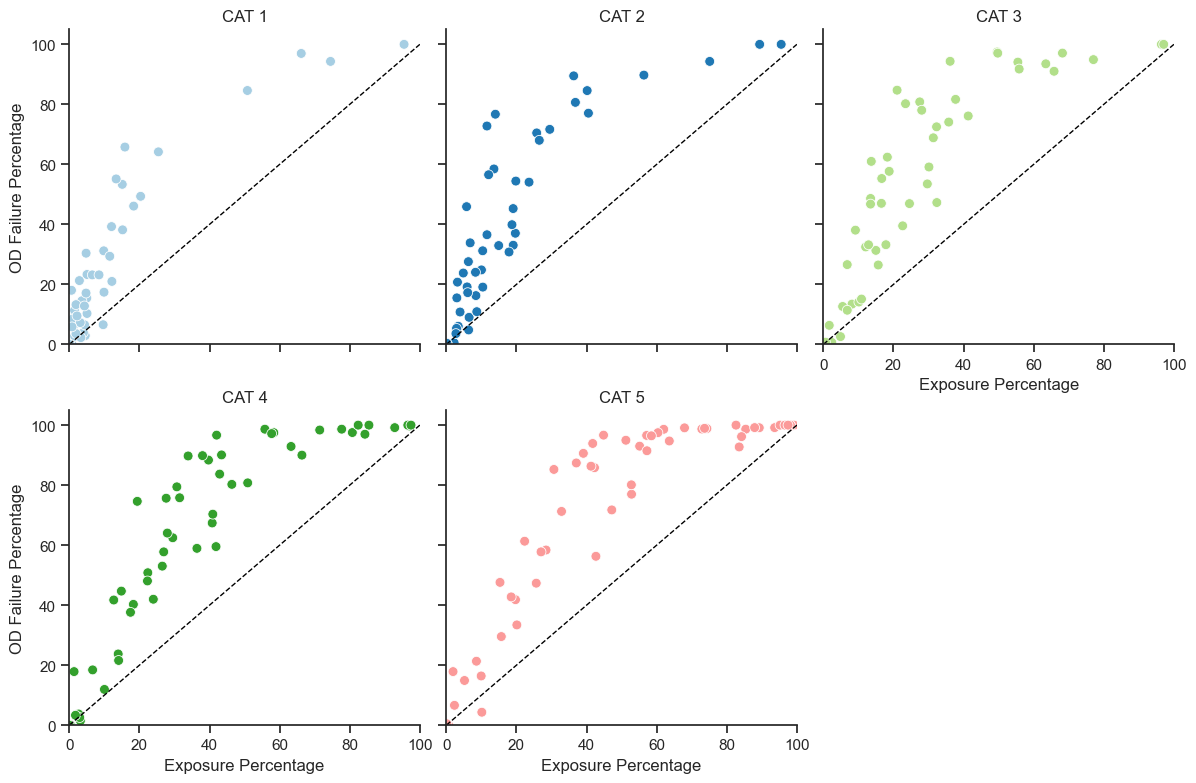

In [ ]:
# col_wrap=3 arranges panels in rows of three. Shared axes (sharex/sharey=True)
# allow direct comparison across panels. The 1:1 reference line is added to
# each facet individually via the ax loop.
cats = [1, 2, 3, 4, 5]
colors = sns.color_palette("Paired", n_colors=len(cats))
color_dict = {f'CAT {cat}': color for cat, color in zip(cats, colors)}

plt.figure(dpi=300, figsize=(10, 10))
# Reshape to long format
df_long = pd.DataFrame()
for cat in cats:
    temp = exposure_failed_merged[[f'CAT{cat}_expo_perc', f'OD_perc_fail_CAT{cat}']].copy()
    temp['Category'] = f'CAT {cat}'
    temp.rename(columns={
        f'CAT{cat}_expo_perc': 'Exposure',
        f'OD_perc_fail_CAT{cat}': 'OD_Failure'
    }, inplace=True)
    df_long = pd.concat([df_long, temp], axis=0)

# Plot with facets and colors
sns.set(style="ticks")
g = sns.relplot(
    data=df_long,
    x='Exposure',
    y='OD_Failure',
    hue='Category',       # Color by category
    palette=color_dict,   # Use custom colors
    col='Category',       # Facets by category
    kind='scatter',
    col_wrap=3,
    height=4,
    aspect=1,
    facet_kws={'sharex': True, 'sharey': True},
    s=50,
    legend=False
)

# Add y=x line to each facet
for ax in g.axes.flatten():
    ax.plot([0, 100], [0, 100], '--', color='black', linewidth=1)
g.set_titles("{col_name}")
g.set(xlim=(0, 100), ylim=(0, 105))
g.set_axis_labels("Exposure Percentage", "OD Failure Percentage")

plt.show()

---
## Figure SI-9 — Aggregated confusion matrix comparing daily precipitation and river discharge return period classes across all study locations.

In [210]:
# compare
flu_plu_df = pd.read_csv('/Users/yiyi/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology(2)/Research/Global road network resilience/01_data/csv/dfo_compound_stats.csv',
                    index_col=0)


In [340]:
col1 = 'fluvial_global_max'
col2 = 'pluvial_global_max'
df = flu_plu_df
df[[col1, col2]] = df[[col1, col2]].replace(2, 1)
res = pd.crosstab(df[col1], df[col2], normalize=True) * 100
res

pluvial_global_max,0.0,1.0,5.0,10.0,20.0,50.0,100.0,200.0,500.0
fluvial_global_max,,,,,,,,,
0.0,23.097546,4.207053,0.721798,0.329965,0.144360,0.082491,0.020623,0.061868,0.000000
1.0,10.249536,9.383378,2.680965,1.402351,0.989895,0.268097,0.144360,0.061868,0.103114
5.0,2.206641,2.825325,1.629202,1.835430,1.257991,0.371211,0.226851,0.061868,0.061868
10.0,1.443597,1.608579,1.154877,1.443597,1.093009,0.474325,0.206228,0.082491,0.000000
20.0,0.845535,1.340483,0.969272,1.257991,1.526088,0.742421,0.433079,0.226851,0.144360
50.0,0.536193,0.639307,0.288719,0.536193,0.928026,0.763044,0.556816,0.371211,0.226851
100.0,0.164982,0.288719,0.123737,0.309342,0.556816,0.618684,0.350588,0.309342,0.288719
200.0,0.144360,0.164982,0.123737,0.185605,0.268097,0.371211,0.536193,0.391833,0.639307
500.0,0.350588,0.371211,0.268097,0.226851,0.824912,0.721798,0.866158,1.443597,4.825737


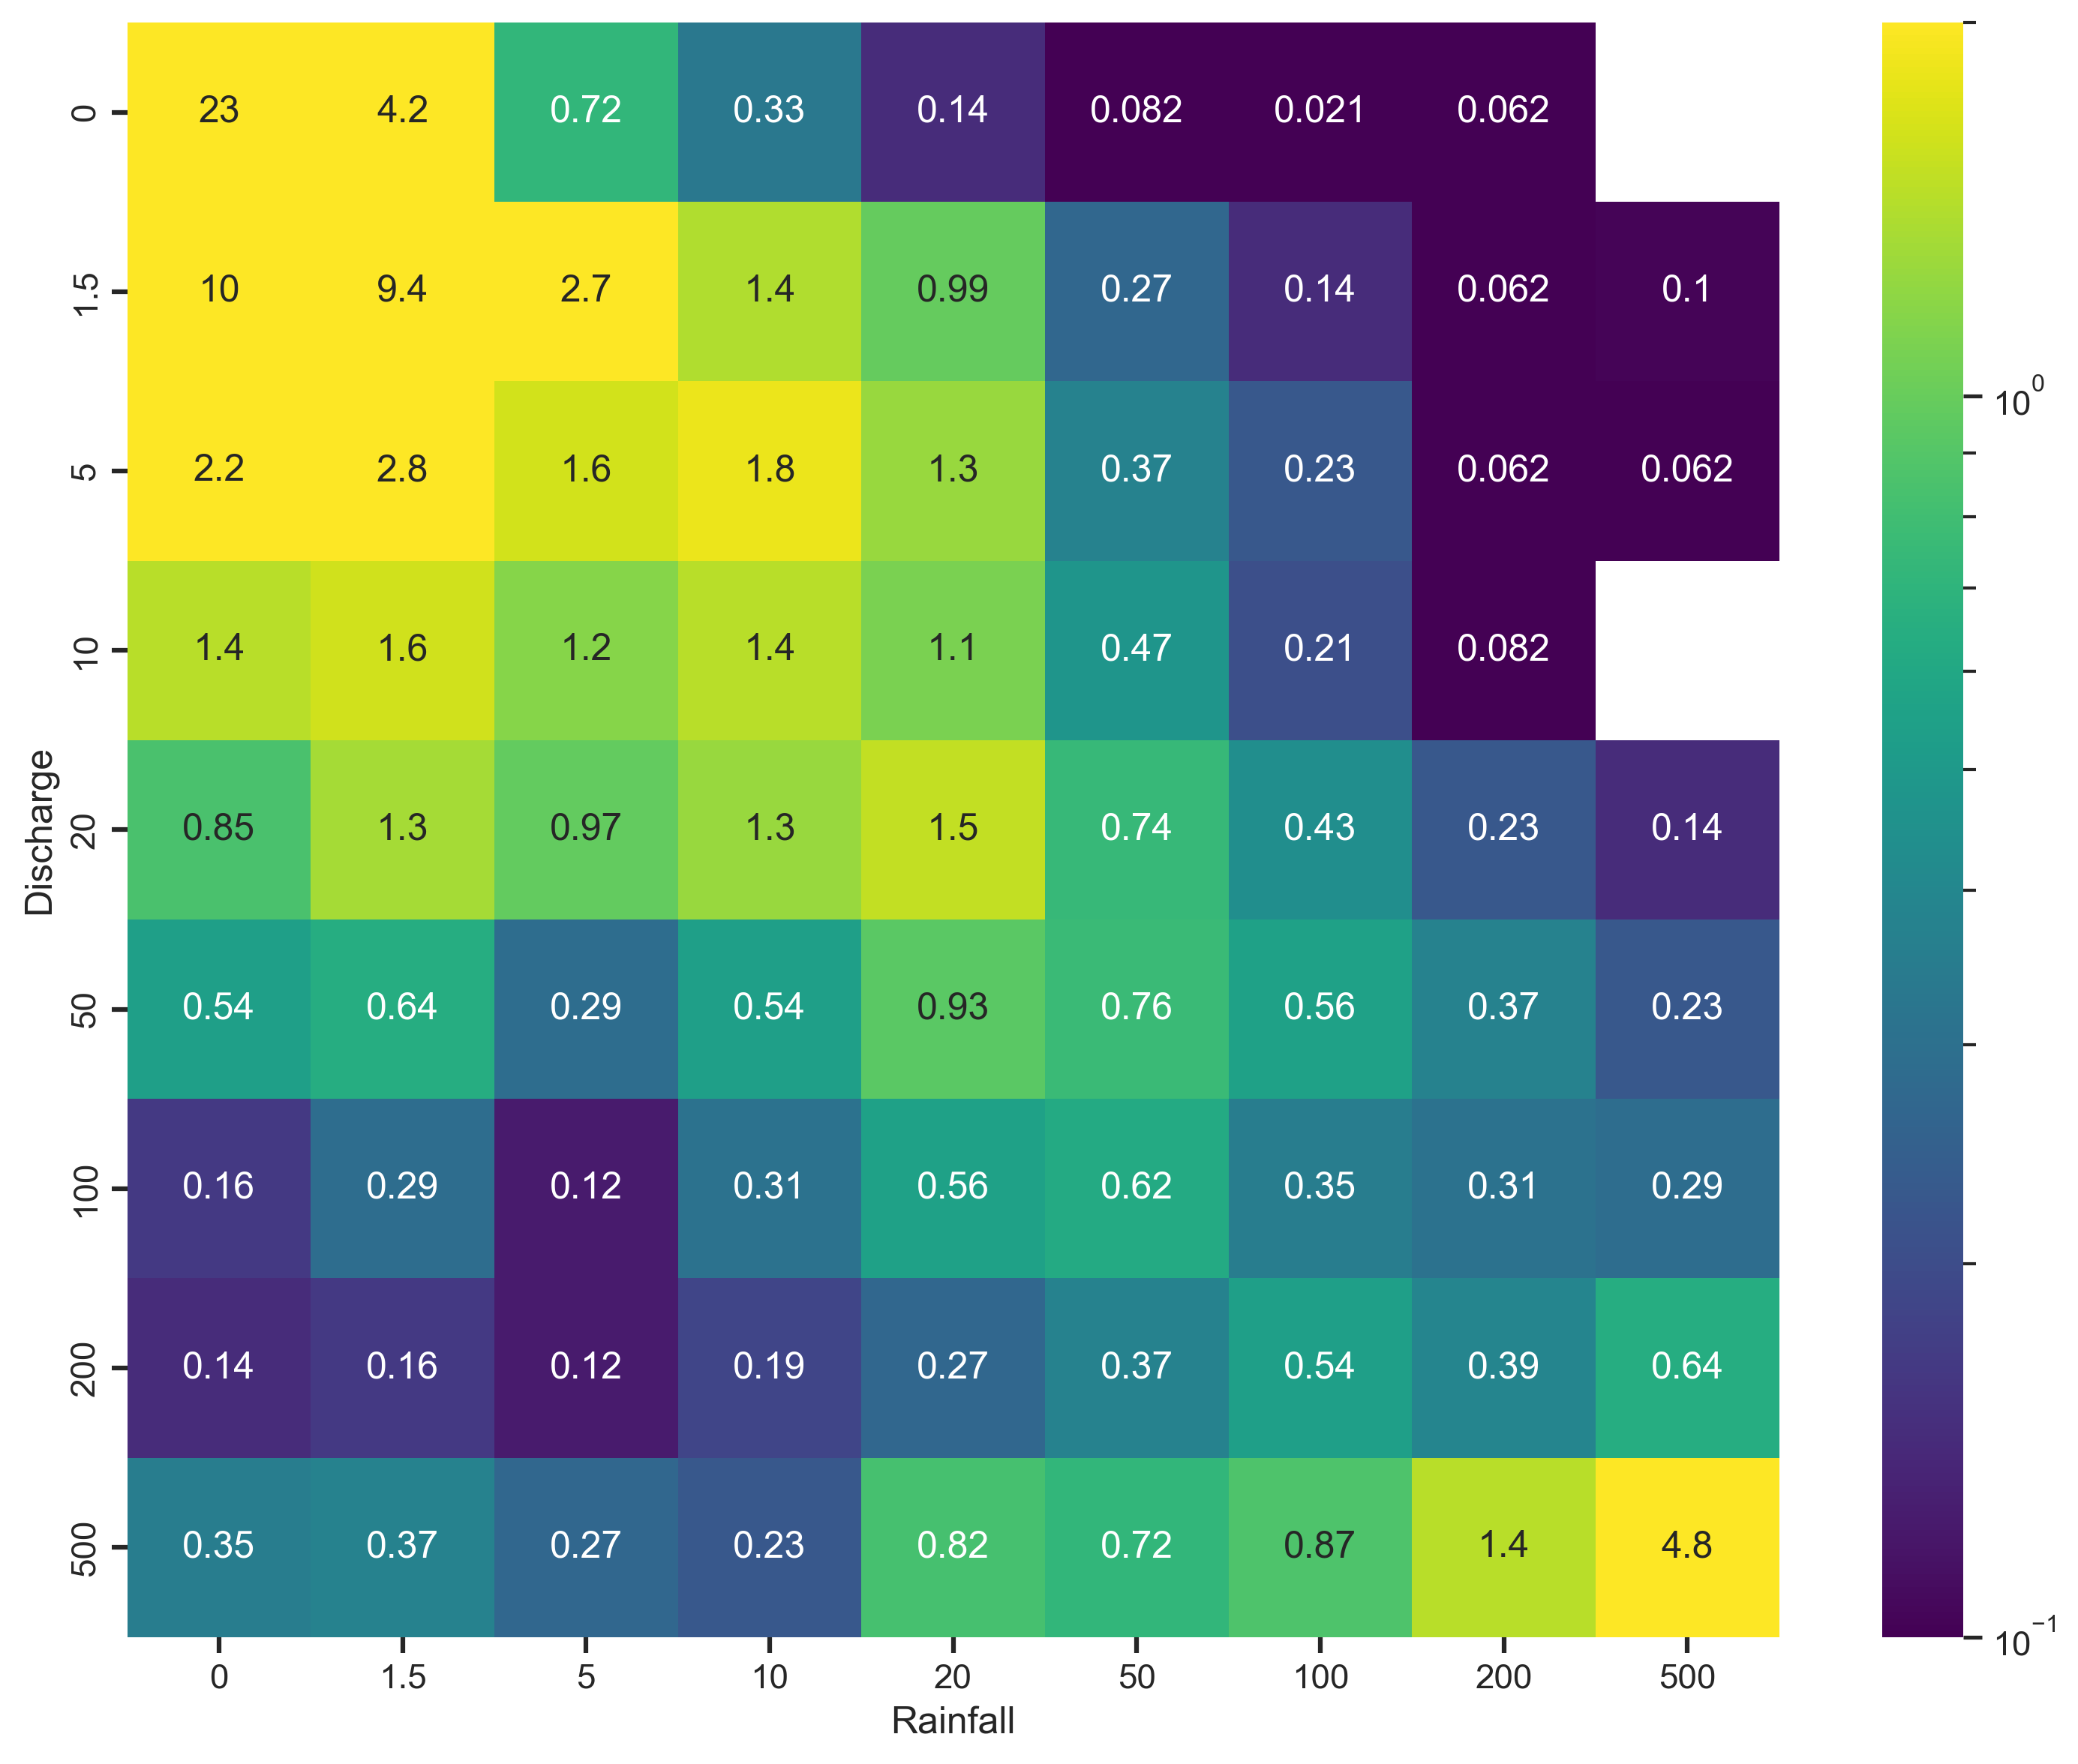

In [348]:
plt.figure(figsize=(10, 8), dpi=300)

bins = [0, 1.5, 5, 10, 20, 50, 100, 200, 500]
sns.heatmap(
    res.values,
    cmap="viridis",
    norm=LogNorm(vmin=0.1, vmax=2),
    annot=True,
    xticklabels=bins,
    yticklabels=bins
    # cbar_kws={"label": "Mean Count (log scale)"}
)

plt.xlabel("Rainfall")
plt.ylabel("Discharge")
# plt.title("Mean Confusion Matrix (Log-scaled Colors)")
plt.tick_params(length=5, width=1.5)
plt.tight_layout()
plt.show()

---
## Figure SI-11b — Global patterns of the relationship between travel frequency and flood inundation levels (b)Density histogram of all coefficients.

In [7]:
# load the coefficients csv file
three_ft_coeff_df = pd.read_csv(home_dir + '/csv/3_ft_parameters_df.csv', index_col=0)

In [8]:
three_ft_coeff_df

,net_id,intercept,exposure_rp100,cosine_depth30cm_freq90th_RP100,gcc_num_nodes_node_norm
0,1,42.523688,25.708259,-0.025745,-14.362636
1,2,41.930256,21.342596,8.373958,-9.503041
2,11,42.970992,26.455734,3.019769,-9.747162
3,101,35.982776,7.342577,10.396185,-17.439932
4,1001,45.064113,5.225114,4.473669,-21.590088
...,...,...,...,...,...
2402,994,46.170201,4.740472,4.839220,-19.157154
2403,995,50.818756,9.371074,-0.166531,-15.174104
2404,996,45.701469,6.132091,2.957744,-22.110768
2405,998,45.415478,7.758297,2.871701,-19.502934


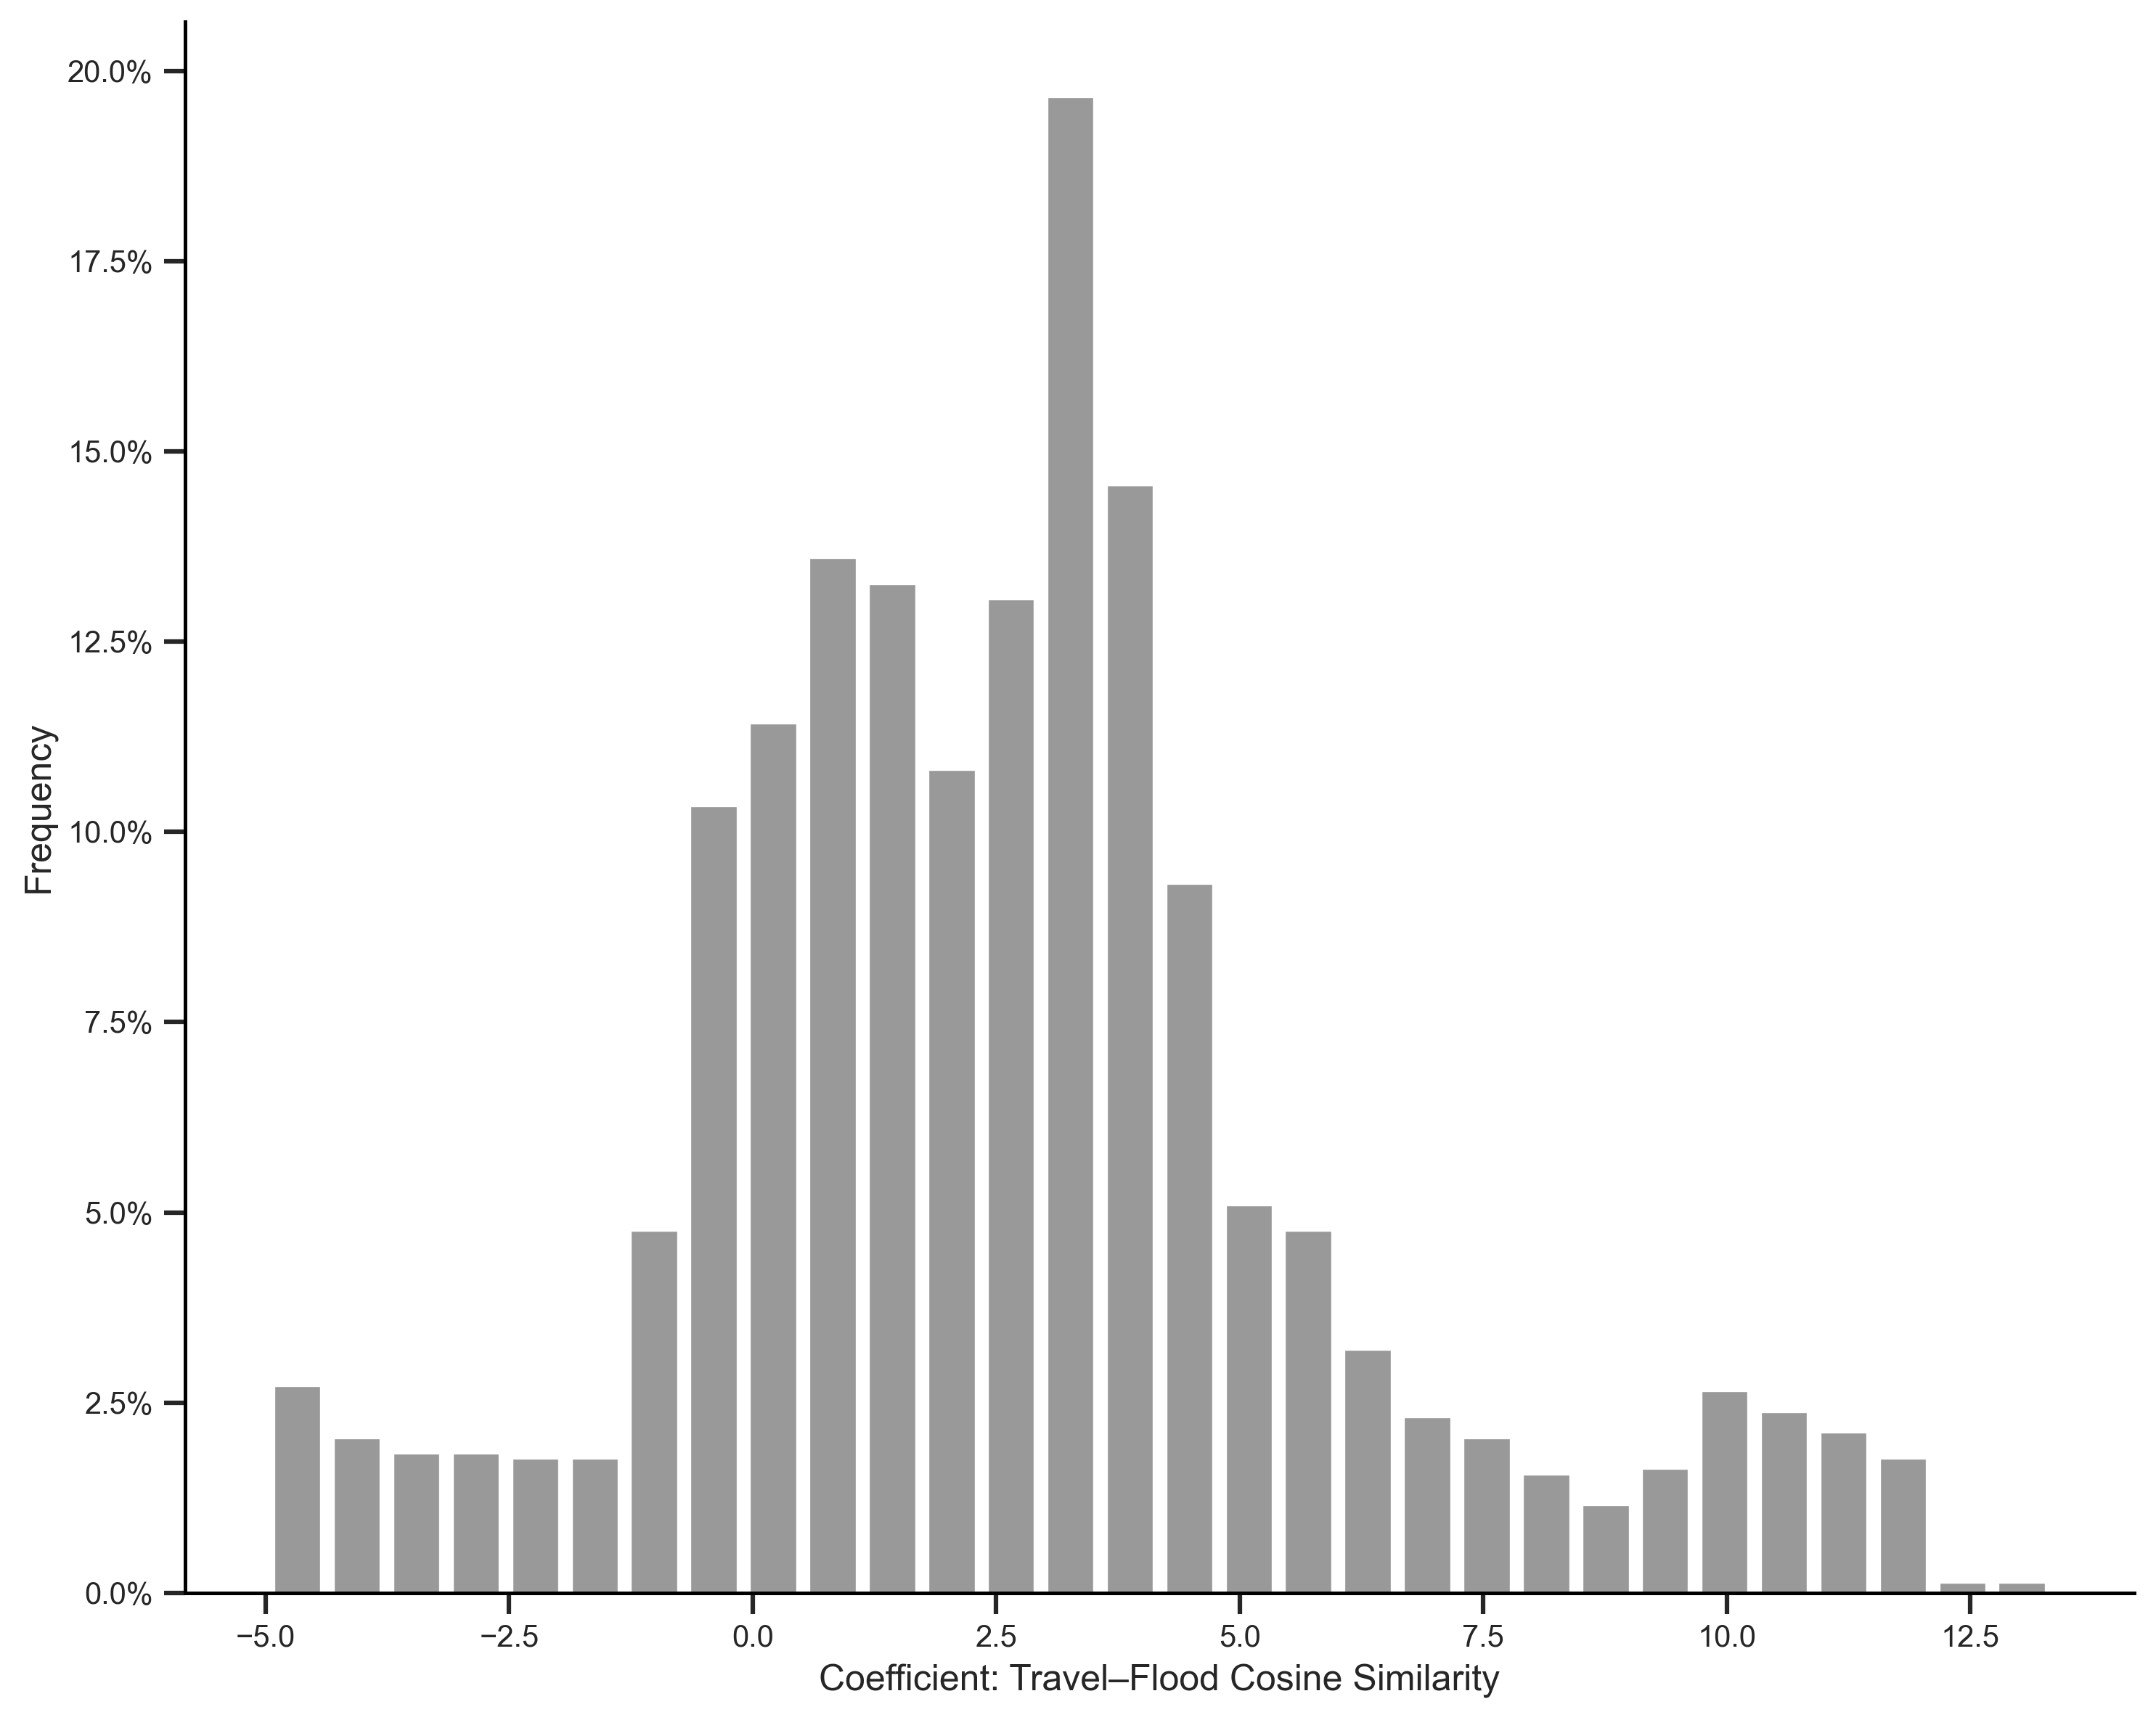

In [86]:
import matplotlib.ticker as mticker
fig, ax = plt.subplots(figsize=(10,8), dpi=300)

coeff_values = three_ft_coeff_df['cosine_depth30cm_freq90th_RP100'].dropna()

ax.hist(
    coeff_values,
    bins=30,
    rwidth=0.8,
    color='0.6',        # neutral gray
    edgecolor='white',  # clean bin separation
    linewidth=0.8,
    density=True
)
# Spine styling (this is the key part)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('black')
    ax.spines[spine].set_linewidth(1.2)

# Remove grid and extra spines
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Labels and title
ax.set_xlabel('Coefficient: Travel–Flood Cosine Similarity', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

# Improve tick appearance
ax.tick_params(axis='both', labelsize=10, length=7, width=1.5)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

---
## Figure SI-12 — Kernel density estimates of the Gini coefficient for road-segment-level travel frequency.

In [42]:
# load the coefficients csv file
three_ft_coeff_df = pd.read_csv(home_dir + '/csv/3_ft_parameters_df.csv', index_col=0)
# Network ids in the US northeast region
US_NE_net_ids = three_ft_coeff_df[three_ft_coeff_df.cosine_depth30cm_freq90th_RP100 < -1.5].net_id.values

# Load edge frequency variance df
edge_gini_df = pd.read_csv('/Users/yiyi/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Research/Global road network resilience/01_data/csv/edge_freq_gini.csv',
                          index_col=0)

# Distribution of US northeast network edge frequency variance
US_NE_values = edge_gini_df[edge_gini_df.net_id.isin(US_NE_net_ids)].edge_freq_gini.values
non_US_NE_values_raw = edge_gini_df[~edge_gini_df.net_id.isin(US_NE_net_ids)].edge_freq_gini.values
non_US_NE_values = non_US_NE_values_raw[~np.isnan(non_US_NE_values_raw)]
np.random.seed(99317)
non_US_NE_values_sample = np.random.choice(non_US_NE_values, size=167, replace=False)

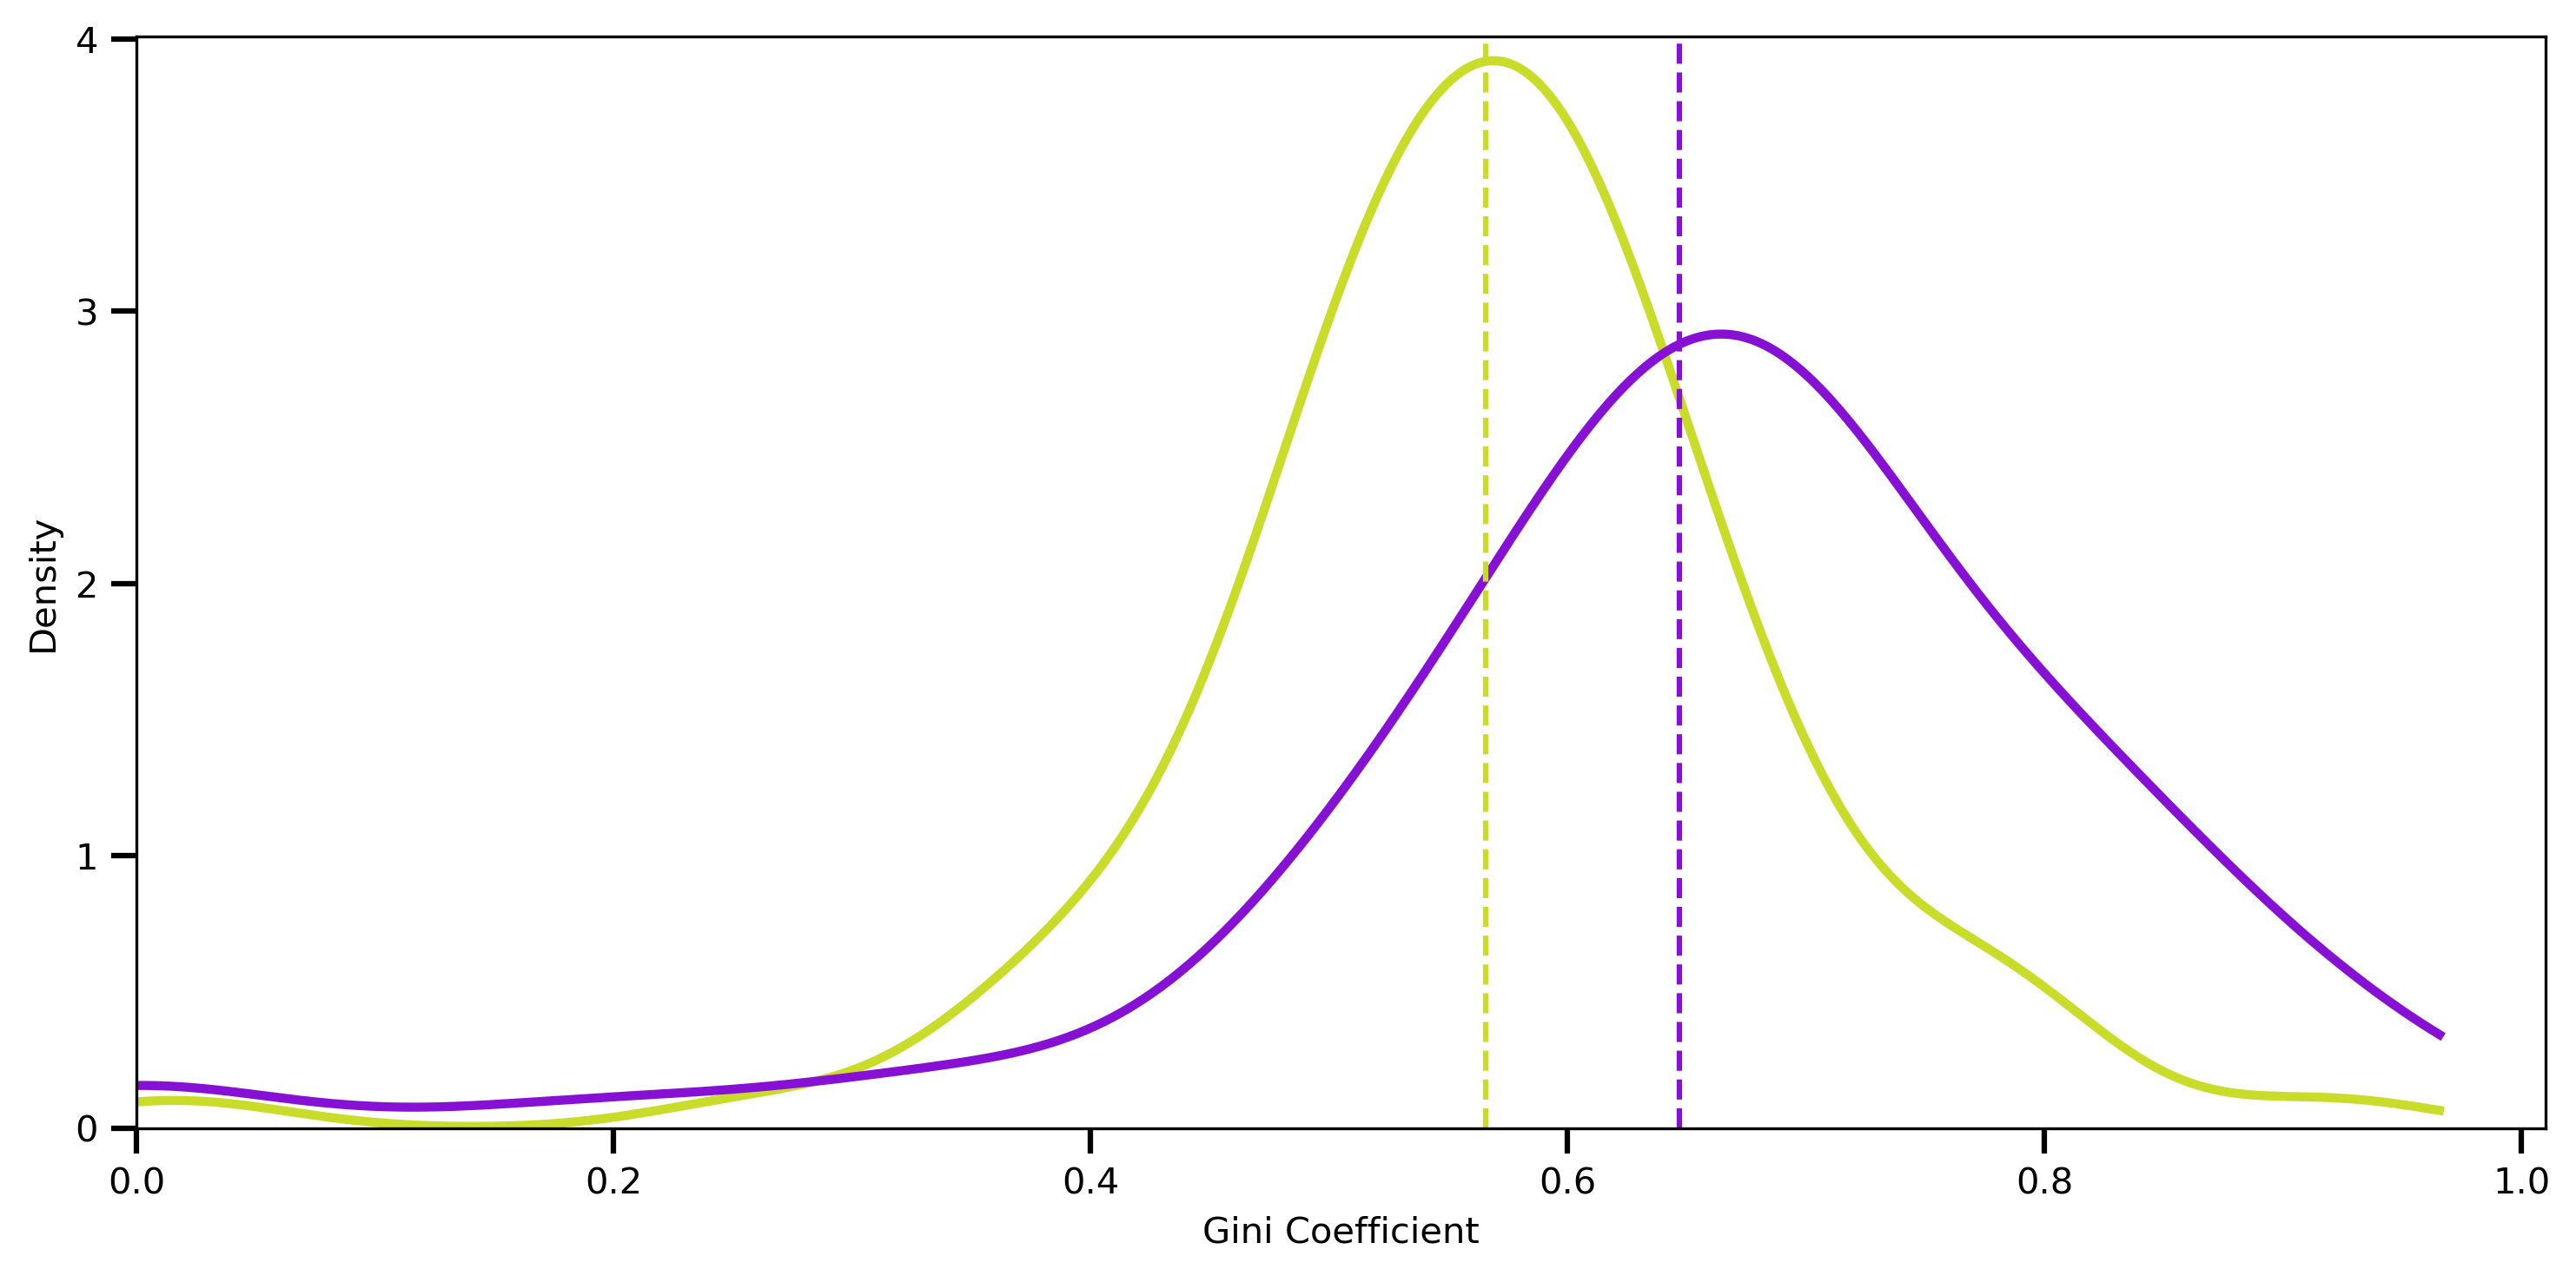

In [60]:
a = np.array(US_NE_values)
b = np.array(non_US_NE_values_sample)

x = np.linspace(min(a.min(), b.min()), max(a.max(), b.max()), 500)

kde_a = gaussian_kde(a)
kde_b = gaussian_kde(b)

plt.figure(figsize=(10,5), dpi=300)
plt.plot(x, kde_a(x), color="#cadc2a", linewidth=2.5, label='US NorthEast')
plt.plot(x, kde_b(x), color="#8611d4", linewidth=2.5, label='Randomly sampled 167 non US North East')

plt.axvline(a.mean(), linestyle='--', color="#cadc2a")
plt.axvline(b.mean(), linestyle='--', color="#8611d4")

plt.xlabel("Gini Coefficient")
plt.ylabel("Density")
plt.xlim(xmin=0, xmax=1.01)
plt.ylim(ymin=0, ymax=4.01)
plt.yticks(np.arange(0, 5, step=1))
plt.tick_params(length=7, width=1.5)
plt.tight_layout()
plt.show()

---
## Figure SI-20e — Validation: Road Closures During Hurricane Harvey

**Metric:** `FUP1k_*cm` — fraction of census tracts where model-predicted flooded
road segments match observed closure reports, at four depth thresholds.

**Figure produced:** Grouped bar histogram of match-percentage distributions.
Bars are coloured from light to dark (shallow to deep threshold), using a
custom four-colour palette. The histogram uses consistent bins across all
thresholds to enable direct comparison.

In [6]:
match_df

,TRACTCE,GEOID,NAME,NAMELSAD,FUP1k_30cm,FUP1k_25cm,FUP1k_20cm,FUP1k_15cm
3,554202,48201554202,5542.02,Census Tract 5542.02,0.0,100.0,100.0,100.0
18,674601,48157674601,6746.01,Census Tract 6746.01,0.0,0.0,100.0,100.0
40,673107,48157673107,6731.07,Census Tract 6731.07,0.0,0.0,100.0,100.0
43,673113,48157673113,6731.13,Census Tract 6731.13,0.0,0.0,100.0,100.0
53,673103,48157673103,6731.03,Census Tract 6731.03,0.0,0.0,100.0,100.0
...,...,...,...,...,...,...,...,...
554,252001,48201252001,2520.01,Census Tract 2520.01,100.0,100.0,100.0,100.0
555,521201,48201521201,5212.01,Census Tract 5212.01,100.0,100.0,100.0,100.0
556,532004,48201532004,5320.04,Census Tract 5320.04,100.0,100.0,100.0,100.0
557,532003,48201532003,5320.03,Census Tract 5320.03,100.0,100.0,100.0,100.0


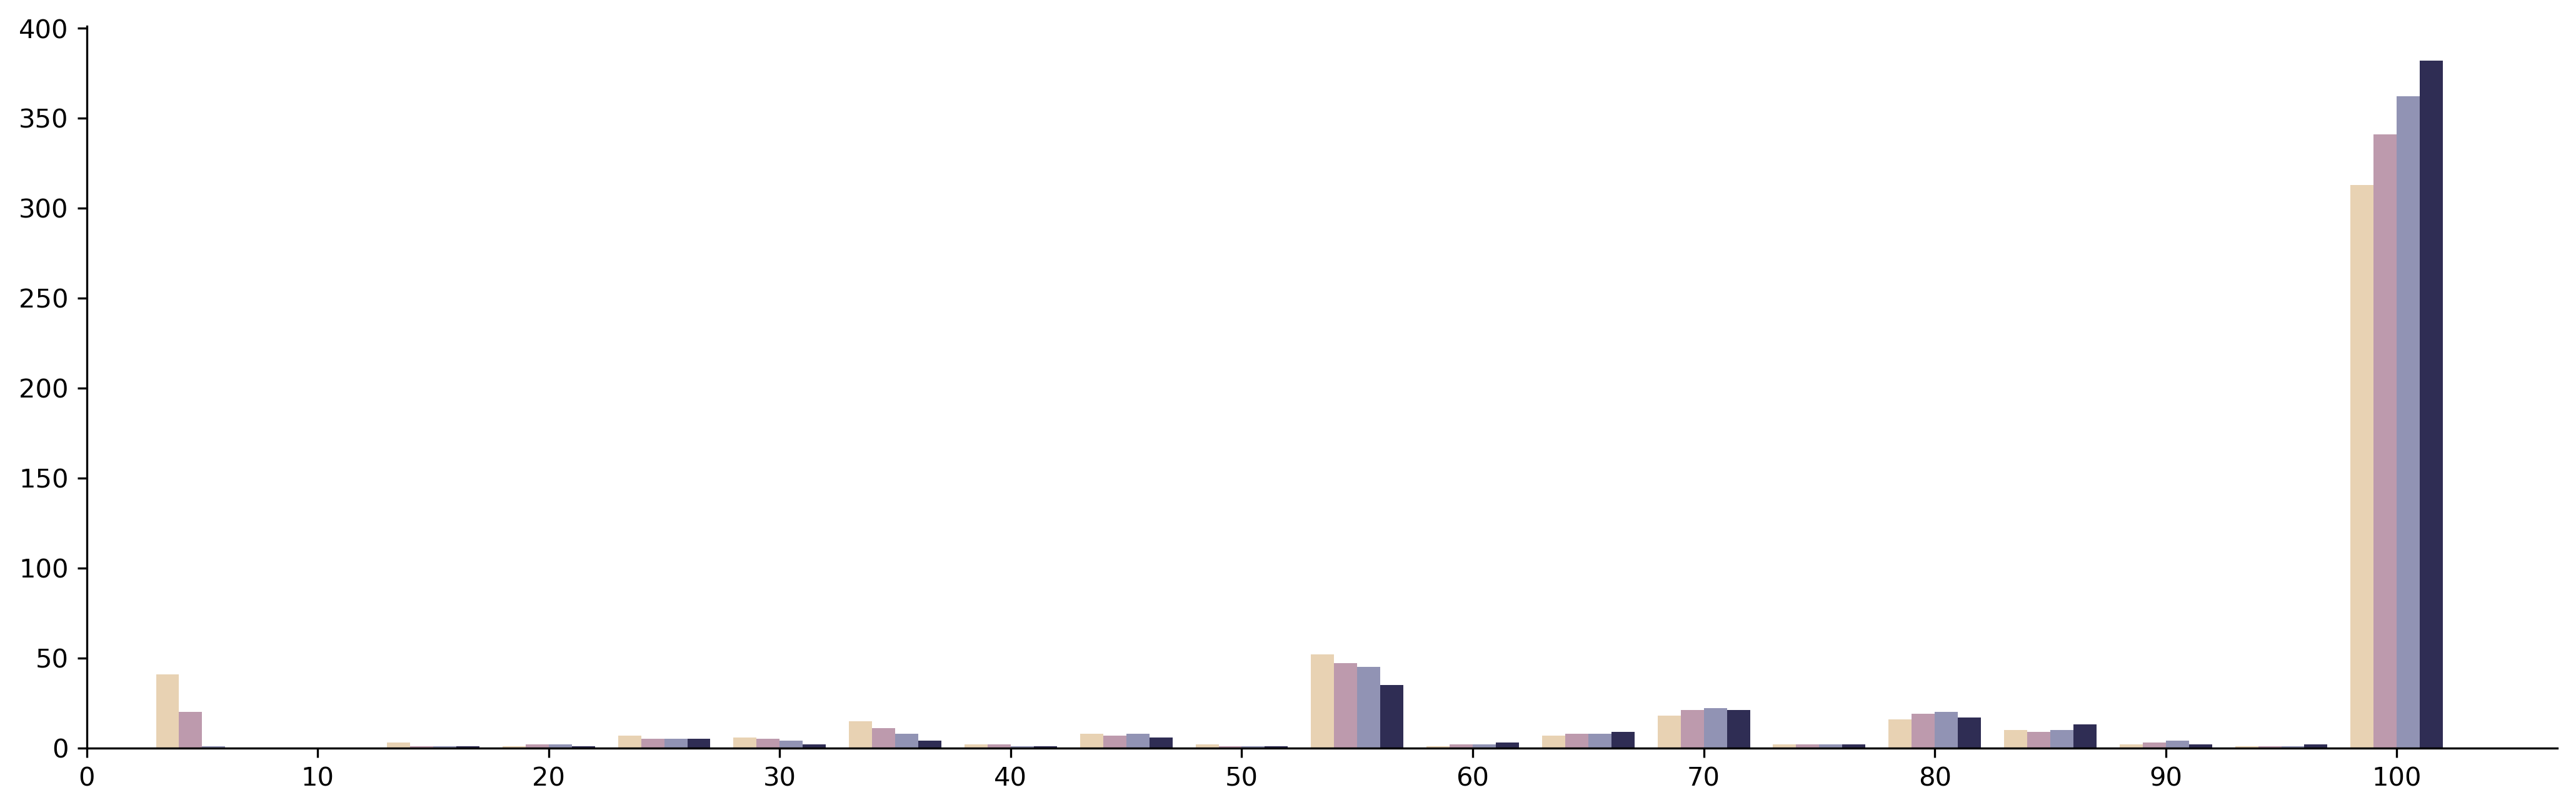

In [5]:
# Load the Harvey validation match-percentage CSV.
# Each row is a census tract; columns FUP1k_30cm … FUP1k_15cm give the
# percentage of flooded road segments in that tract that match observed closures,
# at the indicated depth threshold for a 1000-year return-period flood event.
match_df = pd.read_csv(home_dir + '/public/road_closure_fathom_match_percentage.csv',
                                     index_col=0)


# Common bin edges are derived from the pooled data range so bars from different
# thresholds are directly comparable. Grouped bars are slightly offset within
# each bin by a bar_width calculated from group_width / len(cols).
# Top and right spines are removed for a clean publication style.
cols = ['FUP1k_30cm', 'FUP1k_25cm',
       'FUP1k_20cm', 'FUP1k_15cm']
data = [match_df[c].dropna().values for c in cols]

# Custom colors
colors = ["#E8D2B3", "#BD9AAD","#9193B4", "#2F2D54" ]

# Common bins for all columns
bins = np.histogram_bin_edges(np.concatenate(data), bins=20)

# Spacing control
group_width = 0.8   # <1 adds space between groups
bar_width = (bins[1] - bins[0]) * group_width / len(cols)

fig, ax = plt.subplots(figsize=(17, 5), dpi=300)

# Left edge of each group
group_start = bins[:-1] + (bins[1] - bins[0]) * (1 - group_width) / 2

for i, (col, values) in enumerate(zip(cols, data)):
    counts, _ = np.histogram(values, bins=bins)
    ax.bar(
        group_start + i * bar_width+2.5,
        counts,
        width=bar_width,
        align="edge",
        label=col,
        color=colors[i]
    )

# --- axis settings ---
ax.set_xlim(left=0)
ax.set_xticks(np.arange(0, bins.max() + 10, 10))

# remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


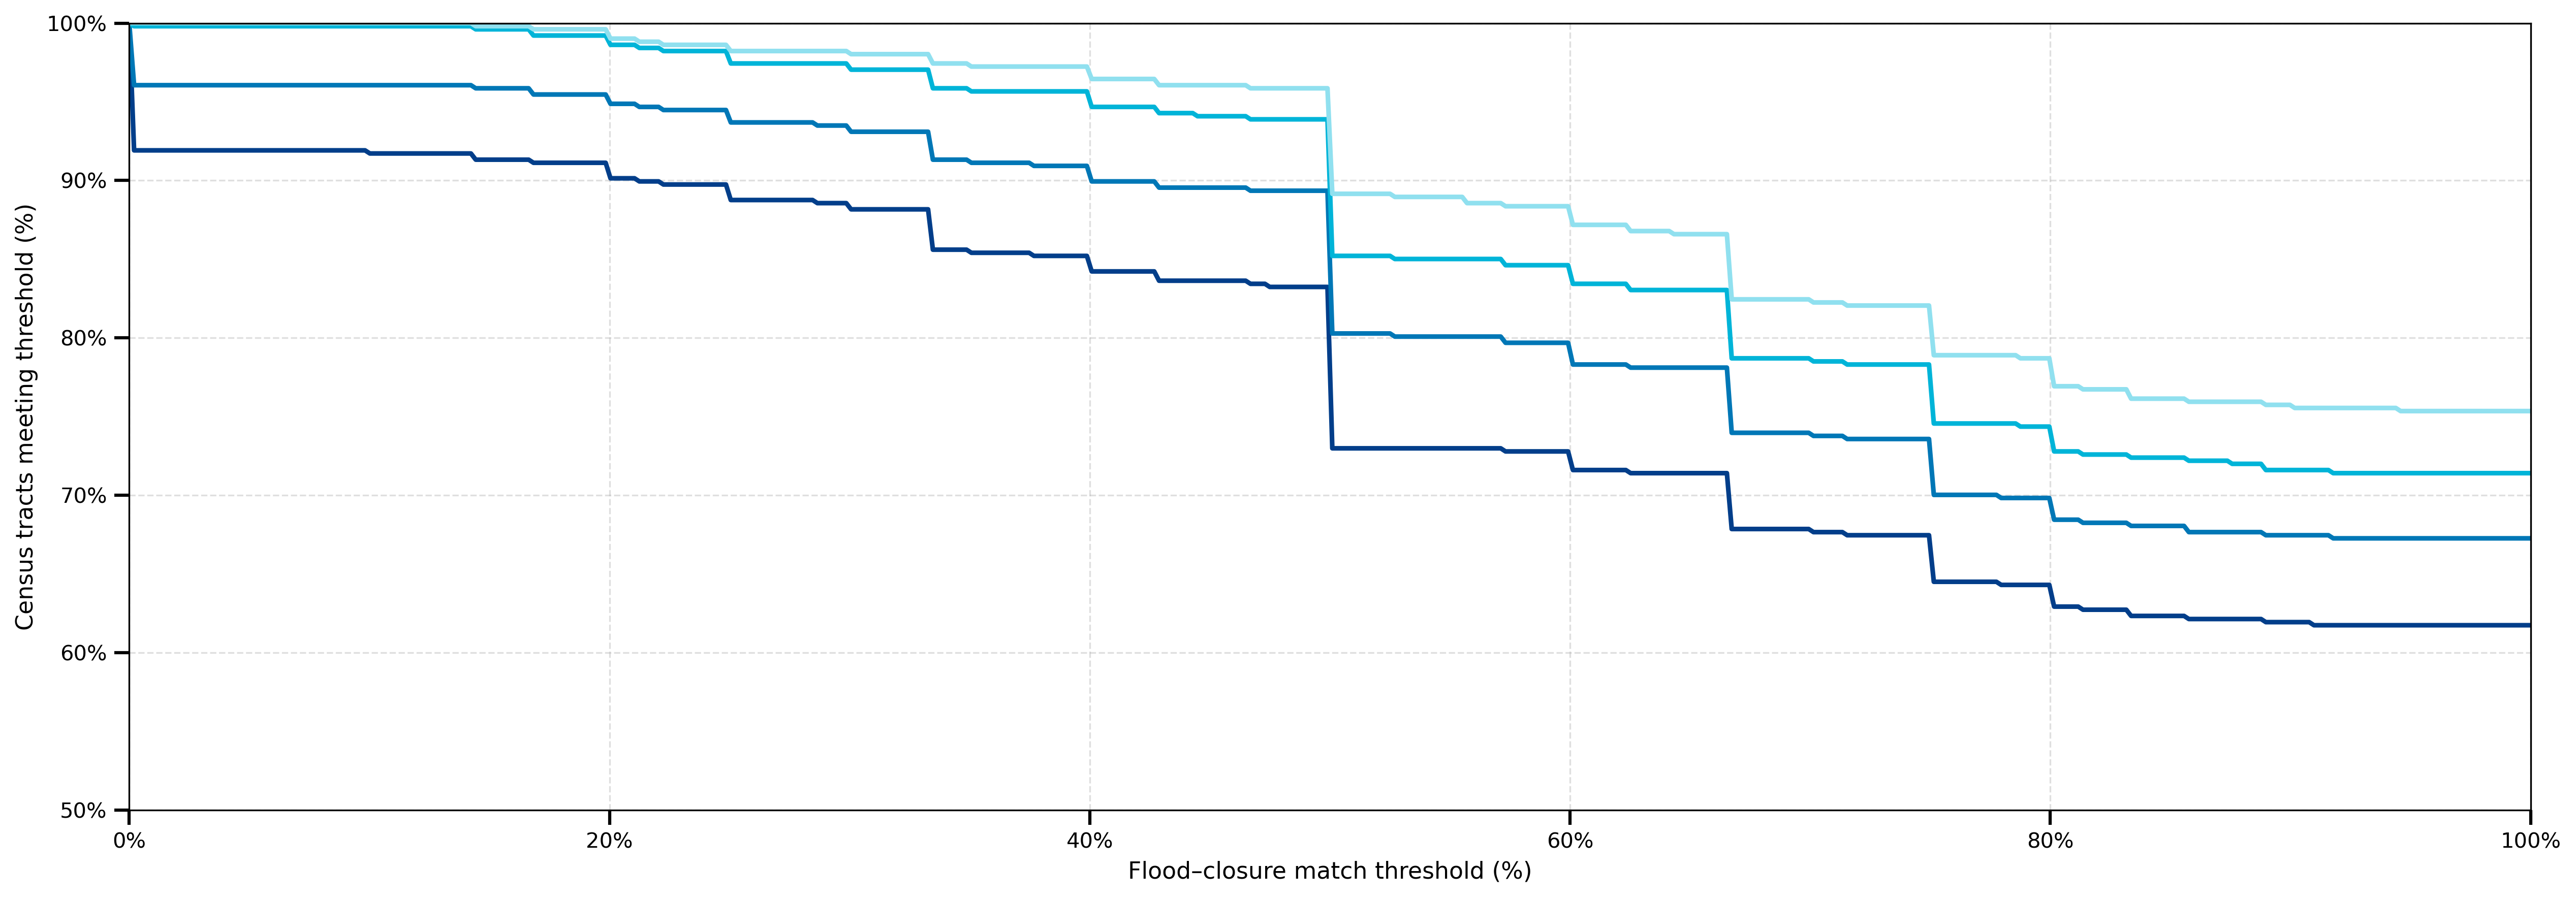

In [21]:
df = match_df
cols = ["FUP1k_30cm", "FUP1k_25cm", "FUP1k_20cm", "FUP1k_15cm"]
colors = ["#023e8a", "#0077b6", "#00b4d8", "#90e0ef"]
labels = ["30 cm", "25 cm", "20 cm", "15 cm"]
 
fig, ax = plt.subplots(figsize=(17, 6), dpi=300)
 
for col, color, label in zip(cols, colors, labels):
    vals = df[col].dropna().values
    n = len(vals)
    # For each threshold x: % of tracts with match >= x
    x = np.linspace(0, 100, 500)
    y = np.array([(vals >= threshold).sum() / n * 100 for threshold in x])
    ax.plot(x, y, color=color, linewidth=2.2, label=label)

 
ax.set_xlabel("Flood–closure match threshold (%)", fontsize=11)
ax.set_ylabel("Census tracts meeting threshold (%)", fontsize=11)
# ax.set_title("Share of Census Tracts Meeting or Exceeding\nEach Match Percentage Threshold", fontsize=14, fontweight="bold")
# ax.legend(title="Depth Threshold", fontsize=11, title_fontsize=11)
ax.set_xlim(0, 100)
ax.set_ylim(50, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.grid(True, linestyle="--", alpha=0.4)
plt.tick_params(length=7, width=1.5)
 
plt.tight_layout()

---
## Figure SI-13 — Distributions of Shannon entropy values for road network density across spatial resolutions.

Compute spatial gini coeff and entropy for US northeastern networks and randomly selected 167 networks from the rest of the world

In [192]:
# load the coefficients csv file
three_ft_coeff_df = pd.read_csv(home_dir + '/csv/3_ft_parameters_df.csv', index_col=0)
# Network ids in the US northeast region
US_NE_net_ids = three_ft_coeff_df[three_ft_coeff_df.cosine_depth30cm_freq90th_RP100 < -1.5].net_id.values

# Randomly sample 167 netids that are not in northeast US
sample_167 = three_ft_coeff_df.loc[~three_ft_coeff_df["net_id"].isin(set(US_NE_net_ids)), "net_id"].sample(n=167, random_state=42).values

In [ ]:
graph_dir = '/Users/yiyi/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology(2)/Research/Global road network resilience/01_data/all_graph_flooded'

# Lists to store results
netids = []
ginis = []
evens = []

for file in tqdm(os.listdir(graph_dir)):
    if file.endswith('pk'):
        # Extract network id
        net_id = int(re.search(r'_r_(\d+)_', file).group(1))
        
        if net_id in sample_167:
            # Load graph file
            g = pickle.load(open(os.path.join(graph_dir, file), 'rb'))

            # extract node coordinates
            nodes = [Point(data['x'], data['y']) for n, data in g.nodes(data=True)]
            nodes_gdf = gpd.GeoDataFrame(geometry=nodes, crs="EPSG:4326")  # make sure projected; EPSG:3857 is WGS 84 / Pseudo-Mercator
            nodes_gdf = nodes_gdf.to_crs("EPSG:3857")


            # Compute convex hull
            convex_hull = nodes_gdf.unary_union.convex_hull

            # Create grid within convex hull
            cell_size = 500  # meters
            minx, miny, maxx, maxy = convex_hull.bounds
            cols = int(np.ceil((maxx - minx) / cell_size))
            rows = int(np.ceil((maxy - miny) / cell_size))

            grid_cells = []
            for i in range(cols):
                for j in range(rows):
                    cell = box(minx + i*cell_size, miny + j*cell_size,
                            minx + (i+1)*cell_size, miny + (j+1)*cell_size)
                    # only keep cells that intersect the convex hull
                    if cell.intersects(convex_hull):
                        grid_cells.append(cell)

            grid = gpd.GeoDataFrame({'geometry': grid_cells}, crs="EPSG:3857")

            # Compute Road Length per Grid Cell
            # Convert edges to GeoDataFrame
            edges = []
            for u, v, data in g.edges(data=True):
                if 'geometry' in data:
                    edges.append(data['geometry'])
                else:
                    x1, y1 = g.nodes[u]['x'], g.nodes[u]['y']
                    x2, y2 = g.nodes[v]['x'], g.nodes[v]['y']
                    edges.append(LineString([(x1, y1), (x2, y2)]))

            edges_gdf = gpd.GeoDataFrame(geometry=edges, crs="EPSG:4326")
            edges_gdf = edges_gdf.to_crs("EPSG:3857")

            # Compute road length per cell
            grid['road_length'] = 0.0
            for idx, cell in grid.iterrows():
                roads_in_cell = edges_gdf[edges_gdf.intersects(cell['geometry'])]
                total_length = roads_in_cell.geometry.intersection(cell['geometry']).length.sum()
                grid.at[idx, 'road_length'] = total_length

            # Compute Shannon evenness
            p = grid['road_length'] / grid['road_length'].sum()
            p = p[p > 0]  # ignore empty cells

            H = -np.sum(p * np.log(p))
            E = H / np.log(len(p))

            # Compute Gini coefficient
            def gini(array):
                array = np.array(array).flatten()
                array = array - np.min(array) + 1e-9  # shift to positive
                array = np.sort(array)
                n = array.size
                index = np.arange(1, n+1)
                return ((np.sum((2*index - n - 1)*array)) / (n*np.sum(array)))

            G = gini(grid['road_length'])

            netids.append(net_id)
            ginis.append(G)
            evens.append(E)

        else:
            continue

# Create new DataFrame
edge_homogeneity_df = pd.DataFrame({
    'net_id': netids,
    'net_gini': ginis,
    'net_shannon': evens
})

# Save to csv file
edge_homogeneity_df.to_csv('/Users/yiyi/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology(2)/Research/Global road network resilience/01_data/csv/Sample_167_road_homogeneity_500m.csv')

In [273]:
US_100m_df = pd.read_csv(home_dir + '/csv/US_northeast_road_homogeneity_100m.csv', index_col=0)
US_200m_df = pd.read_csv(home_dir + '/csv/US_northeast_road_homogeneity_200m.csv', index_col=0)
US_500m_df = pd.read_csv(home_dir + '/csv/US_northeast_road_homogeneity_500m.csv', index_col=0)
random_100m_df = pd.read_csv(home_dir + '/csv/Sample_167_road_homogeneity_100m.csv', index_col=0)
random_200m_df = pd.read_csv(home_dir + '/csv/Sample_167_road_homogeneity_200m.csv', index_col=0)
random_500m_df = pd.read_csv(home_dir + '/csv/Sample_167_road_homogeneity_500m.csv', index_col=0)

US = [US_100m_df.net_shannon.values, US_200m_df.net_shannon.values, US_500m_df.net_shannon.values]
Random = [random_100m_df.net_shannon.values, random_200m_df.net_shannon.values, random_500m_df.net_shannon.values]

/var/folders/cy/f8598vm53cggn74m01d5s0rc0000gr/T/ipykernel_71296/2557808029.py:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False, ncol=2)


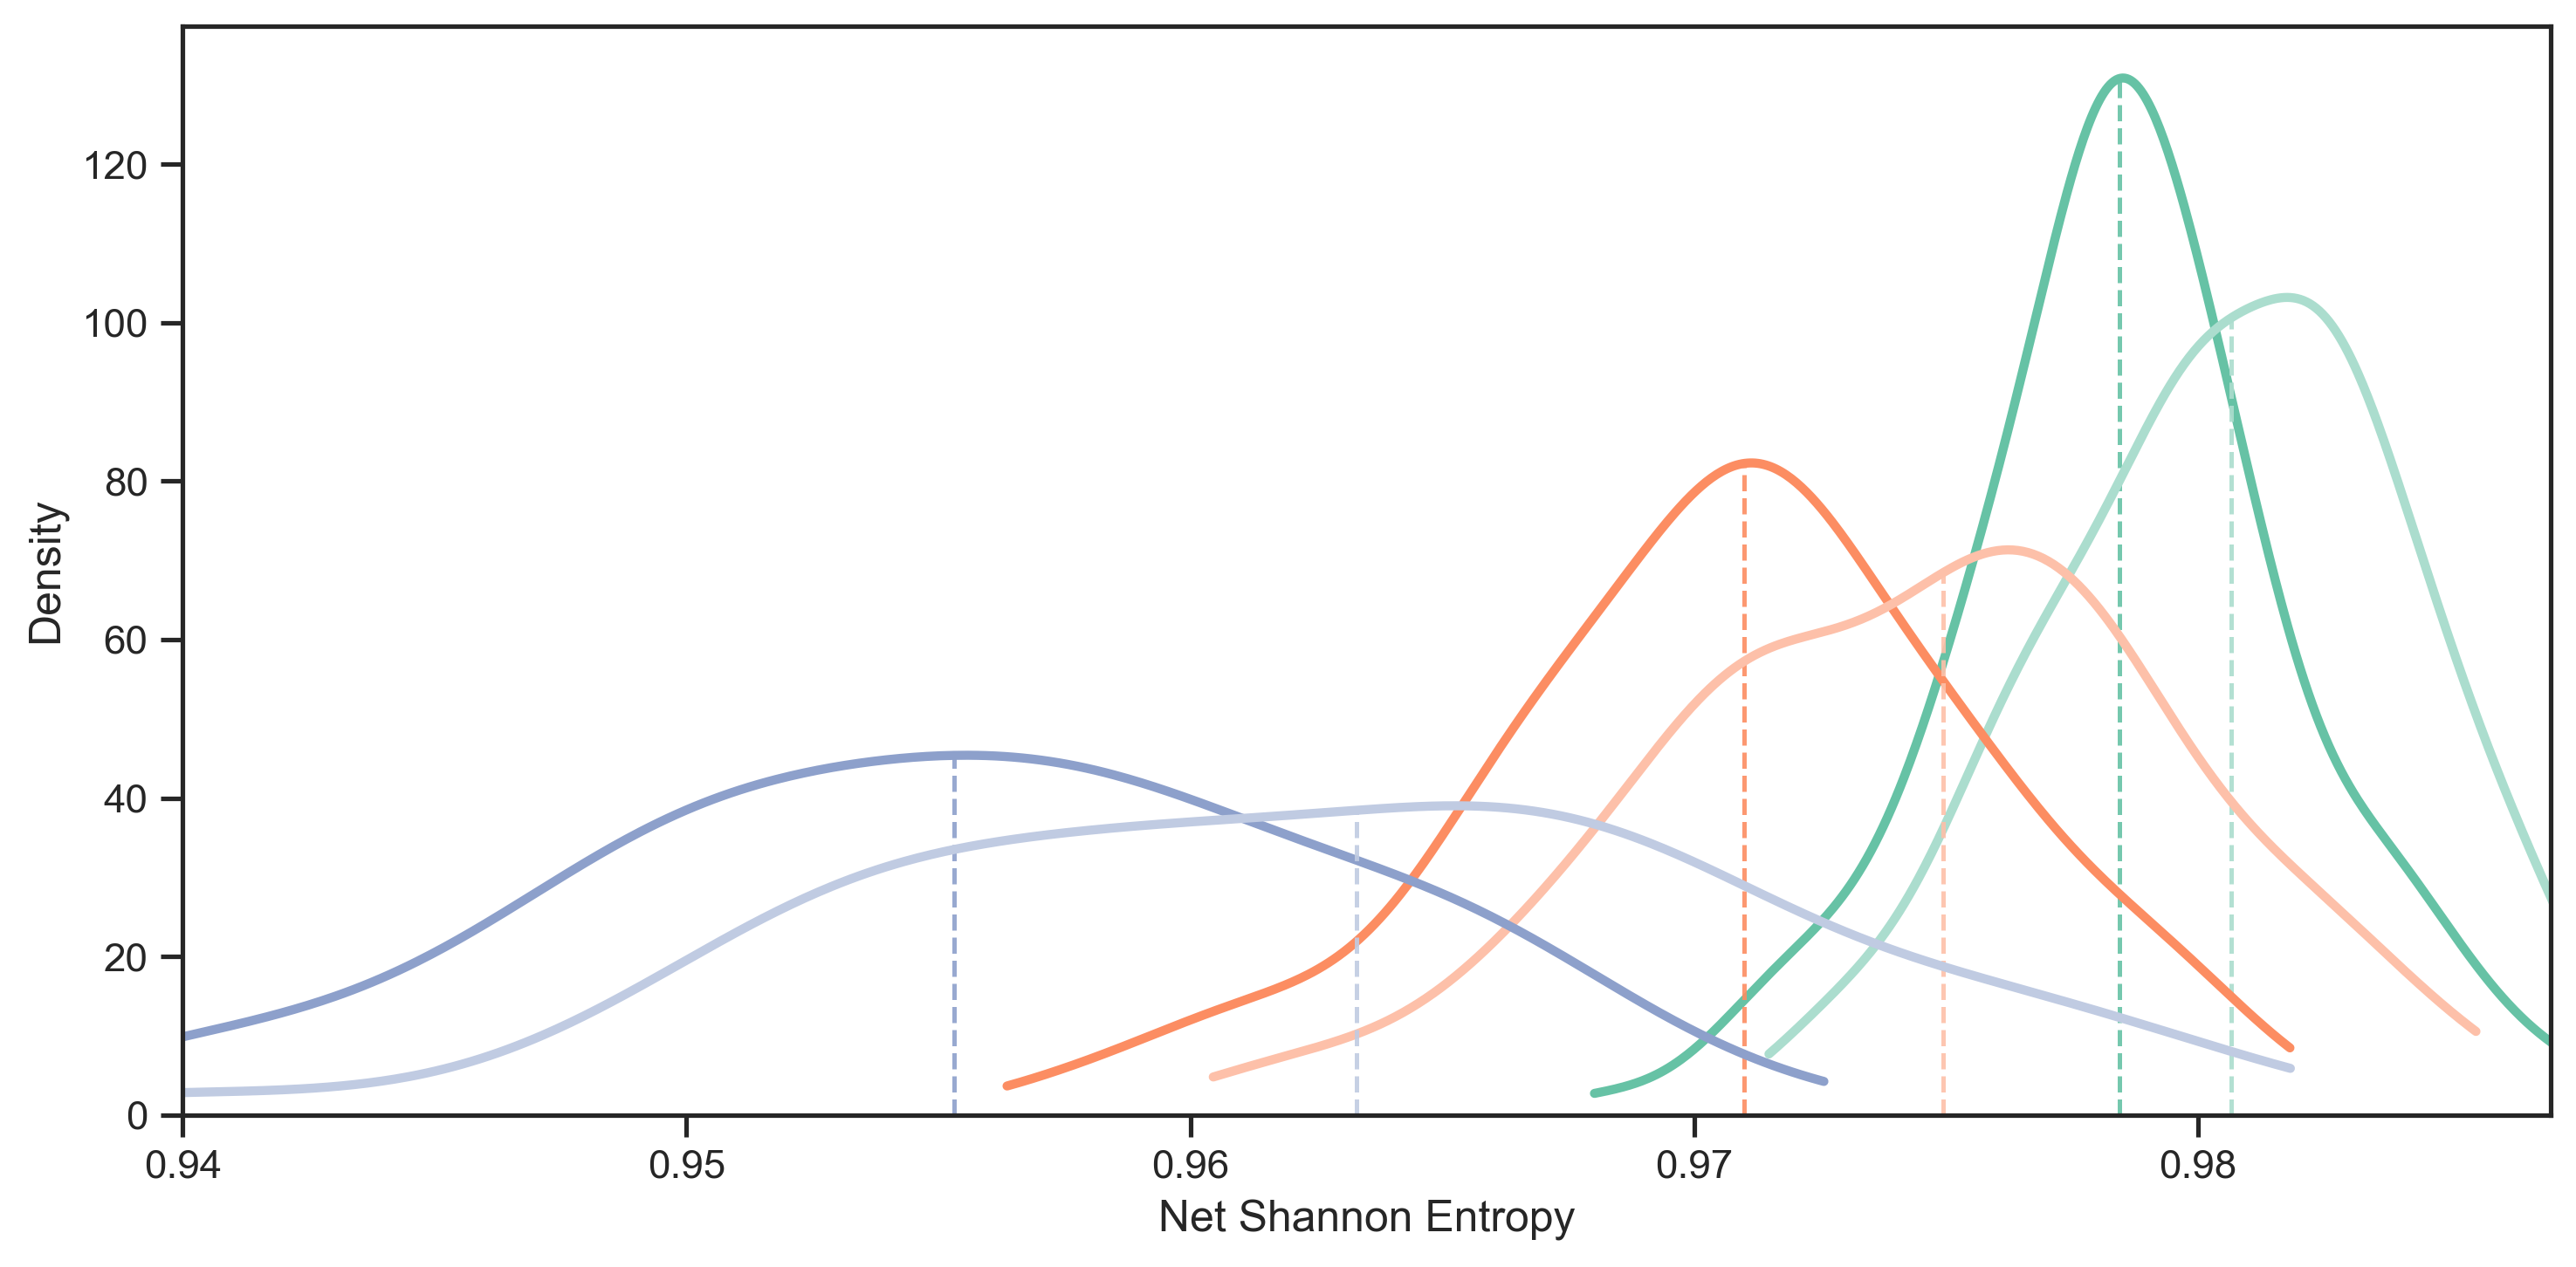

In [274]:
sns.set(style="ticks")
plt.figure(figsize=(10, 5), dpi=300)

# Base colors for scales
base_colors = sns.color_palette("Set2", 3)
scales = ["100 m", "200 m", "500 m"]

def lighten_color(color, amount=0.45):
    """Lighten color by blending with white"""
    r, g, b = color
    return (r + (1 - r) * amount,
            g + (1 - g) * amount,
            b + (1 - b) * amount)

scale_colors = {
    scale: base_colors[i]
    for i, scale in enumerate(scales)
}

US = {
    "100 m": US_100m_df.net_shannon.values,
    "200 m": US_200m_df.net_shannon.values,
    "500 m": US_500m_df.net_shannon.values,
}

Random = {
    "100 m": random_100m_df.net_shannon.values,
    "200 m": random_200m_df.net_shannon.values,
    "500 m": random_500m_df.net_shannon.values,
}

# ---- Plot KDEs + medians (clipped to curve) ----
for scale in scales:
    color_dark = scale_colors[scale]
    color_light = lighten_color(color_dark, amount=0.45)

    # ---------- US ----------
    arr = US[scale]
    kde = gaussian_kde(arr)
    x = np.linspace(arr.min(), arr.max(), 500)
    y = kde(x)

    plt.plot(x, y, color=color_dark, linewidth=2.5)

    median = np.median(arr)
    median_height = kde(median)[0]

    plt.vlines(
        median,
        ymin=0,
        ymax=median_height,
        color=color_dark,
        linestyles="--",
        linewidth=1.2,
        alpha=0.9
    )

    # ---------- Random ----------
    arr = Random[scale]
    kde = gaussian_kde(arr)
    x = np.linspace(arr.min(), arr.max(), 500)
    y = kde(x)

    plt.plot(x, y, color=color_light, linewidth=2.5)

    median = np.median(arr)
    median_height = kde(median)[0]

    plt.vlines(
        median,
        ymin=0,
        ymax=median_height,
        color=color_light,
        linestyles="--",
        linewidth=1.2,
        alpha=0.9
    )

plt.xlabel("Net Shannon Entropy")
plt.ylabel("Density")
plt.xticks(np.arange(0.93, 1.00, 0.01))
plt.xlim(0.94, 0.987)
plt.ylim(bottom=0)

plt.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()